In [ ]:
!pip install biopython
!pip install pubchempy
import pandas as pd
from Bio import Entrez
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import pandas as pd
import pubchempy as pcp

First Source for Database-mining: **UniProt**, link: https://www.uniprot.org/

In [ ]:
import pandas as pd
from IPython.display import display

protein_data = []

def search(info):
  protein_name = info["proteinDescription"]["recommendedName"]["fullName"]["value"]
  length = info["sequence"]["length"]
  mol_weight = info["sequence"]["molWeight"]
  organism= info["organism"]["scientificName"]

  subcellular_location = "Not available"
  for comment in info.get("comments", []):
      if comment.get("commentType") == "SUBCELLULAR LOCATION" and "subcellularLocations" in comment:
          if comment["subcellularLocations"]:
              subcellular_location = comment["subcellularLocations"][0]["location"]["value"]
              break
  protein_data.append({
      "Protein Name": protein_name,
      "Organism": organism,
      "Length": length,
      "Molecular Weight": mol_weight,
      "Subcellular Location": subcellular_location
})

def find(link):
  current_info = requests.get(link).json()
  search(current_info)

find("https://rest.uniprot.org/uniprotkb/O00501.json")#claud-5
find("https://www.uniprot.org/uniprotkb/Q9JKD6.json")#claud-5-rat
find("https://www.uniprot.org/uniprotkb/P56749.json")#claud-12
find("https://www.uniprot.org/uniprotkb/Q9ET43.json")#claud-12-rat
find("https://www.uniprot.org/uniprotkb/O15551.json")#claudin-3
find("https://www.uniprot.org/uniprotkb/Q63400.json")#claudin-3-rat
find("https://www.uniprot.org/uniprotkb/Q16625.json")#occludin
find("https://www.uniprot.org/uniprotkb/Q6P6T5.json")#occludin-rat
find("https://www.uniprot.org/uniprotkb/Q8N4S9.json")#tricellulin
find("https://www.uniprot.org/uniprotkb/Q3UZP0.json")#tricellulin-rat

df = pd.DataFrame(protein_data)

output_filename = "protein_info.csv"
df.to_csv(output_filename, index=False)
print(f"Data saved to {output_filename}")

display(df)

Data saved to protein_info.csv


,Protein Name,Organism,Length,Molecular Weight,Subcellular Location
0,Claudin-5,Homo sapiens,218,23147,"Cell junction, tight junction"
1,Claudin-5,Rattus norvegicus,218,23072,"Cell junction, tight junction"
2,Claudin-12,Homo sapiens,244,27110,"Cell junction, tight junction"
3,Claudin-12,Mus musculus,244,26995,"Cell junction, tight junction"
4,Claudin-3,Homo sapiens,220,23319,"Cell junction, tight junction"
5,Claudin-3,Rattus norvegicus,219,23315,"Cell junction, tight junction"
6,Occludin,Homo sapiens,522,59144,Cell membrane
7,Occludin,Rattus norvegicus,523,59186,Cell membrane
8,MARVEL domain-containing protein 2,Homo sapiens,558,64168,Cell membrane
9,MARVEL domain-containing protein 2,Mus musculus,555,63662,Cell membrane


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1TiuQlmSIS3UhHEQUBAN-B6cC-2T76WokiclECJYNEBs/edit#gid=0


Second Source of Database-mining: **PubChem**, link: https://pubchem.ncbi.nlm.nih.gov/

In [ ]:
!pip install pubchempy

import pandas as pd
import pubchempy as pcp

chemical_analysis = []

def chem(compound_name):
  compound_search=pcp.get_compounds(compound_name,'name')[0]
  chemical_actualname=compound_name
  chem_name=compound_search.iupac_name
  MF=compound_search.molecular_formula
  MW=compound_search.molecular_weight
  HBA=compound_search.h_bond_acceptor_count
  HBD=compound_search.h_bond_donor_count
  XlogP=compound_search.xlogp

  approx = "Not Sourced"
  if XlogP is not None:
    if XlogP < -1:
      approx="Polar"
    elif XlogP > 1:
      approx="Nonpolar"
    elif XlogP >= -1 and XlogP < 0:
      approx="Slightly Polar"
    elif XlogP >= 0 and XlogP <= 1:
      approx="Slightly Nonpolar"

  chemical_analysis.append({
      "Chemical Name:": chemical_actualname,
      "IUPAC Name:":chem_name,
      "MF:": MF,
      "MW:": MW,
      "WPC/OPC:": XlogP,
      "Polarity:": approx,
      "Hydrogen Bond Acceptor Count": HBA,
      "Hydrogen Bond Donor Count": HBD
  })

chem("Levodopa")
chem("Carbidopa")
chem("Levetiracetam")
chem("Gabapentin")
chem("Phenobarbital")
chem("Phenytoin")
chem("Diazepam")
chem("Buspirone")
chem("Ceftriaxone")
chem("Vancomycin")
chem("Fluconazole")
chem("Temozolomide")
chem("Lomustine")
chem("Methotrexate")
chem("Carmustine")
chem("Etoposide")
chem("Vorasidenib")
chem("Tovorafenib")
chem("Dexamethasone")
chem("Metronidazole")
chem("Doxorubicin")
chem("Paclitaxel")
chem("Erlotinib")
chem("Loperamide")
chem("Gefitinib")

df=pd.DataFrame(chemical_analysis)
output_filename="chemical.csv"
df.to_csv(output_filename, index=False)
print(f"Data saved to {output_filename}")

display(df)


Data saved to chemical.csv


,Chemical Name:,IUPAC Name:,MF:,MW:,WPC/OPC:,Polarity:,Hydrogen Bond Acceptor Count,Hydrogen Bond Donor Count
0,Levodopa,"(2S)-2-amino-3-(3,4-dihydroxyphenyl)propanoic ...",C9H11NO4,197.19,-2.7,Polar,5,4
1,Carbidopa,"(2S)-3-(3,4-dihydroxyphenyl)-2-hydrazinyl-2-me...",C10H14N2O4,226.23,-2.2,Polar,6,5
2,Levetiracetam,(2S)-2-(2-oxopyrrolidin-1-yl)butanamide,C8H14N2O2,170.21,-0.3,Slightly Polar,2,1
3,Gabapentin,2-[1-(aminomethyl)cyclohexyl]acetic acid,C9H17NO2,171.24,-1.1,Polar,3,2
4,Phenobarbital,"5-ethyl-5-phenyl-1,3-diazinane-2,4,6-trione",C12H12N2O3,232.23,1.5,Nonpolar,3,2
5,Phenytoin,"5,5-diphenylimidazolidine-2,4-dione",C15H12N2O2,252.27,2.5,Nonpolar,2,2
6,Diazepam,"7-chloro-1-methyl-5-phenyl-3H-1,4-benzodiazepi...",C16H13ClN2O,284.74,3.0,Nonpolar,2,0
7,Buspirone,8-[4-(4-pyrimidin-2-ylpiperazin-1-yl)butyl]-8-...,C21H31N5O2,385.50,2.6,Nonpolar,6,0
8,Ceftriaxone,"(6R,7R)-7-[[(2Z)-2-(2-amino-1,3-thiazol-4-yl)-...",C18H18N8O7S3,554.60,-1.3,Polar,13,4
9,Vancomycin,"(1S,2R,18R,19R,22S,25R,28R,40S)-48-[(2S,3R,4S,...",C66H75Cl2N9O24,1449.20,-2.6,Polar,26,19


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/16hjvpAtURpOFVOhdftCYDo1sgAJILgBlByIx4wfkY04/edit#gid=0


Graphic Depiction of PubChem Stat

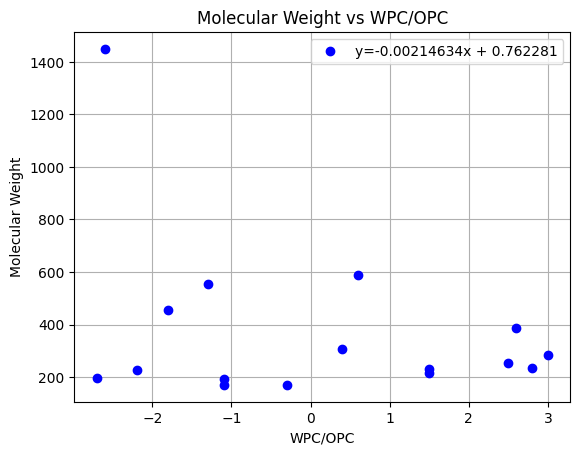

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = df["WPC/OPC:"]
y = df["MW:"]

m = -0.00214634
b = 0.762281

line = m * x + b

plt.xlabel("WPC/OPC")
plt.ylabel("Molecular Weight")
plt.title("Molecular Weight vs WPC/OPC")

plt.plot(df["WPC/OPC:"], df["MW:"],'o', color='blue', label=f'y={m}x + {b}')
plt.grid(True)
plt.legend()
plt.show()

Math Analysis (Diffusion Equations), **Standard Conditions**



In [ ]:
import math
import pandas as pd
import pubchempy as pcp

CI = ["Levodopa", "Carbidopa", "Levetiracetam", "Gabapentin", "Phenobarbital", "Phenytoin", "Diazepam", "Buspirone", "Ceftriaxone", "Vancomycin", "Fluconazole", "Temozolomide", "Lomustine", "Methotrexate", "Carmustine", "Etoposide", "Vorasidenib", "Tovorafenib", "Dexamethasone", "Metronidazole", "Doxorubicin", "Paclitaxel", "Erlotinib", "Loperamide", "Gefitinib"]
refrac_li = [49.55, 57.19, 48.37, 47.48, 67.63, 77.50, 87.95, 118.70, 134.18, 346.61, 70.71, 44.40, 59.08, 118.4, 46.77, 139.11, 86.29, 111.43, 101.96, 43.25, 132.66, 218.96, 111.40, 142.18, 121.66]

def diffusion_eq(chemical_name, i, C, d, k, T, n, beta):
  compound_search=pcp.get_compounds(chemical_name,'name')[0]
  MW=compound_search.molecular_weight
  v = i * 10**-6
  inside = (3 * v) / (4 * math.pi * 6.022 * 10**23)
  radii = (inside) ** (1/3)
  SR = radii
  F = (k * T) / (6 * math.pi * n * SR)
  diffusion_D = F
  J = -1 * F * (C / d)
  Jflux = float(J)
  Absolute = abs(Jflux)
  return {
      "Chemical Name": chemical_name,
      "Spherical Radius": SR,
      "Diffusion Constant": diffusion_D,
      "J-Flux": Jflux,
      "Molecular Weight": MW,
      "J-Magnitude": Absolute,
      "Attributes": f"Beta = {beta}, Standard"
  }
aT = 310
ak = 1.380649 * 10**-23
an = 0.004
ad = 2e-7
aC = 1
beta = 1

calculations = []

for idx in range(len(CI)):
  chemical_name = CI[idx]
  i = refrac_li[idx]
  result = diffusion_eq(chemical_name, i, aC, ad, ak, aT, an, beta)
  calculations.append(result)

df = pd.DataFrame(calculations)
output_filename="calculations_standard_cond.csv"
df.to_csv(output_filename, index=False)
print(f"Data saved to {output_filename}")
display(df)

import google.colab as colab
colab.files.download(output_filename)

Data saved to calculations_standard_cond.csv


,Chemical Name,Spherical Radius,Diffusion Constant,J-Flux,Molecular Weight,J-Magnitude,Attributes
0,Levodopa,2.698183e-10,2.103839e-10,-0.001052,197.19,0.001052,"Beta = 1, Standard"
1,Carbidopa,2.830285e-10,2.005643e-10,-0.001003,226.23,0.001003,"Beta = 1, Standard"
2,Levetiracetam,2.676592e-10,2.120809e-10,-0.001060,170.21,0.001060,"Beta = 1, Standard"
3,Gabapentin,2.660074e-10,2.133979e-10,-0.001067,171.24,0.001067,"Beta = 1, Standard"
4,Phenobarbital,2.992977e-10,1.896621e-10,-0.000948,232.23,0.000948,"Beta = 1, Standard"
5,Phenytoin,3.132017e-10,1.812424e-10,-0.000906,252.27,0.000906,"Beta = 1, Standard"
6,Diazepam,3.266897e-10,1.737594e-10,-0.000869,284.74,0.000869,"Beta = 1, Standard"
7,Buspirone,3.610276e-10,1.572329e-10,-0.000786,385.50,0.000786,"Beta = 1, Standard"
8,Ceftriaxone,3.760851e-10,1.509377e-10,-0.000755,554.60,0.000755,"Beta = 1, Standard"
9,Vancomycin,5.160248e-10,1.100052e-10,-0.000550,1449.20,0.000550,"Beta = 1, Standard"


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

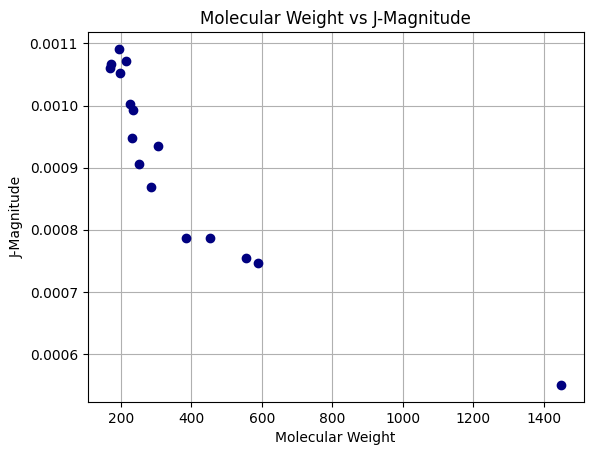

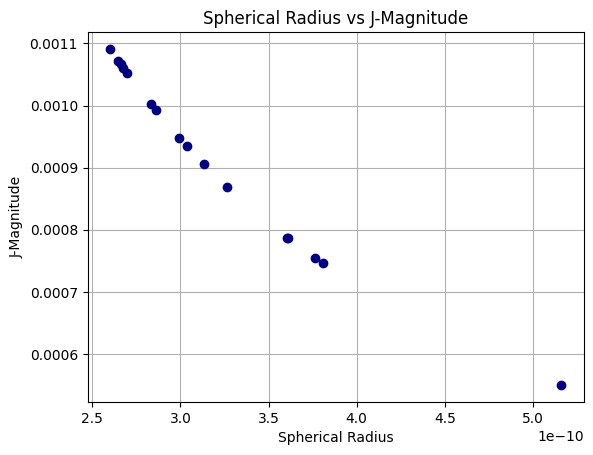

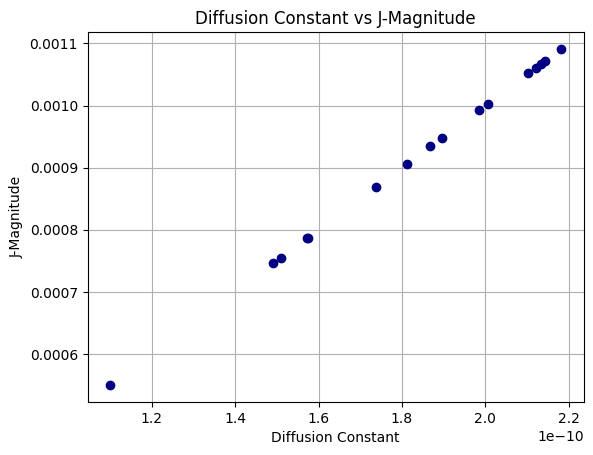

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def generate_graph(x,y,color_rn):
  x_d = df[f"{x}"]
  y_d = df[f"{y}"]
  plt.xlabel(f"{x}")
  plt.ylabel(f"{y}")
  plt.title(f"{x} vs {y}")
  plt.plot(x_d,y_d,'o',color=color_rn)
  plt.grid(True)
  plt.show()

generate_graph("Molecular Weight","J-Magnitude","navy")
generate_graph("Spherical Radius","J-Magnitude","navy")
generate_graph("Diffusion Constant","J-Magnitude","navy")

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1-_iQeyUlmhouTGWMelDztj8Zhvm6YNjRny5tbPjHT_o/edit#gid=0


**Changing Conditions** (Test here)

In [ ]:
import math
import pandas as pd

CI = ["Levodopa", "Carbidopa", "Levetiracetam", "Gabapentin", "Phenobarbital", "Phenytoin", "Diazepam", "Buspirone", "Ceftriaxone", "Vancomycin", "Fluconazole", "Temozolomide", "Lomustine", "Methotrexate", "Carmustine", "Etoposide",  "Vorasidenib", "Tovorafenib", "Dexamethasone", "Metronidazole", "Doxorubicin", "Paclitaxel", "Erlotinib", "Loperamide", "Gefitinib"]
refrac_li = [49.55, 57.19, 48.37, 47.48, 67.63, 77.50, 87.95, 118.70, 134.18, 346.61, 70.71, 44.40, 59.08, 118.40, 46.77, 139.11, 86.29, 111.43, 101.96, 43.25, 132.66, 218.96, 111.40, 142.18, 121.66]

def diffusion_eq(chemical_name, i, C, d, k, T, n, beta):
  v = i * 10**-6
  inside = (3 * v) / (4 * math.pi * 6.022 * 10**23)
  radii = (inside) ** (1/3)
  SR = radii
  n_new = beta * n
  F = (k * T) / (6 * math.pi * n_new * SR)
  diffusion_D = F
  J = -1 * F * (C / d)
  Jflux = float(J)
  Absolute = abs(Jflux)
  return {
      "Chemical Name": chemical_name,
      "Spherical Radius": SR,
      "Diffusion Constant": diffusion_D,
      "J-Flux": Jflux,
      "J-Magnitude": Absolute,
      "Attributes": f"Beta = {n_new}"
  }
aT = 310
ak = 1.380649 * 10**-23
an = 0.004
ad = 2e-7
aC = 1
beta = 2

calculations = []

for idx in range(len(CI)):
  chemical_name = CI[idx]
  i = refrac_li[idx]
  result = diffusion_eq(chemical_name, i, aC, ad, ak, aT, an, beta)
  calculations.append(result)

output_filename="calculations_changing_cond.csv"
df.to_csv(output_filename, index=False)
print(f"Data saved to {output_filename}")
df = pd.DataFrame(calculations)
display(df)

import google.colab as colab
colab.files.download(output_filename)

Data saved to calculations_changing_cond.csv


,Chemical Name,Spherical Radius,Diffusion Constant,J-Flux,J-Magnitude,Attributes
0,Levodopa,2.698183e-10,1.051919e-10,-0.000526,0.000526,Beta = 0.008
1,Carbidopa,2.830285e-10,1.002821e-10,-0.000501,0.000501,Beta = 0.008
2,Levetiracetam,2.676592e-10,1.060405e-10,-0.000530,0.000530,Beta = 0.008
3,Gabapentin,2.660074e-10,1.066989e-10,-0.000533,0.000533,Beta = 0.008
4,Phenobarbital,2.992977e-10,9.483104e-11,-0.000474,0.000474,Beta = 0.008
5,Phenytoin,3.132017e-10,9.062119e-11,-0.000453,0.000453,Beta = 0.008
6,Diazepam,3.266897e-10,8.687971e-11,-0.000434,0.000434,Beta = 0.008
7,Buspirone,3.610276e-10,7.861645e-11,-0.000393,0.000393,Beta = 0.008
8,Ceftriaxone,3.760851e-10,7.546885e-11,-0.000377,0.000377,Beta = 0.008
9,Vancomycin,5.160248e-10,5.500261e-11,-0.000275,0.000275,Beta = 0.008


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Find graph of heuristic based on calculated mathematical values**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pull_calculations = pd.read_csv('calculations.csv')
pull_names = pull_calculations['Chemical Name']
pull_Jmag = pull_calculations['J-Magnitude']
pull_diffusion = pull_calculations['Diffusion Constant']

alpha_const = -1 * pull_Jmag * 10**4
beta_const = pull_diffusion / 200
epsilon_const = 20

combined_new = pd.DataFrame({
    'Chemical Name': pull_names,
    'J-Magnitude': pull_Jmag,
    'Diffusion Constant': pull_diffusion,
    'Alpha Value': alpha_const,
    'Beta Value': beta_const,
    'Epsilon Correction': epsilon_const
})

combined_new['Heuristic'] = combined_new.apply(
    lambda row: f"f(x) = [{row['Alpha Value']}]x**2 + [{row['Beta Value']}]x + [{row['Epsilon Correction']}]",
    axis=1
)

display(combined_new)

output_filename_2 = "equations.csv"
combined_new.to_csv(output_filename_2, index=False)
print(f"Data saved to {output_filename_2}")

colab.files.download(output_filename_2)


,Chemical Name,J-Magnitude,Diffusion Constant,Alpha Value,Beta Value,Epsilon Correction,Heuristic
0,Levodopa,0.001052,2.103839e-10,-10.519193,1.051919e-12,20,f(x) = [-10.519193249426001]x**2 + [1.05191932...
1,Carbidopa,0.001003,2.005643e-10,-10.028215,1.002821e-12,20,f(x) = [-10.028214645342]x**2 + [1.00282146453...
2,Levetiracetam,0.001060,2.120809e-10,-10.604047,1.060405e-12,20,f(x) = [-10.604046515668]x**2 + [1.06040465156...
3,Gabapentin,0.001067,2.133979e-10,-10.669893,1.066989e-12,20,f(x) = [-10.669893465026]x**2 + [1.06698934650...
4,Phenobarbital,0.000948,1.896621e-10,-9.483104,9.483104e-13,20,f(x) = [-9.483104233411]x**2 + [9.483104233411...
5,Phenytoin,0.000906,1.812424e-10,-9.062119,9.062119e-13,20,f(x) = [-9.062118824254]x**2 + [9.062118824254...
6,Diazepam,0.000869,1.737594e-10,-8.687971,8.687971e-13,20,f(x) = [-8.687971188247]x**2 + [8.687971188247...
7,Buspirone,0.000786,1.572329e-10,-7.861645,7.861645e-13,20,f(x) = [-7.861644722459]x**2 + [7.861644722459...
8,Ceftriaxone,0.000755,1.509377e-10,-7.546885,7.546885e-13,20,f(x) = [-7.546884858536]x**2 + [7.546884858536...
9,Vancomycin,0.000550,1.100052e-10,-5.500261,5.500261e-13,20,f(x) = [-5.500260901711]x**2 + [5.500260901711...


Data saved to equations.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

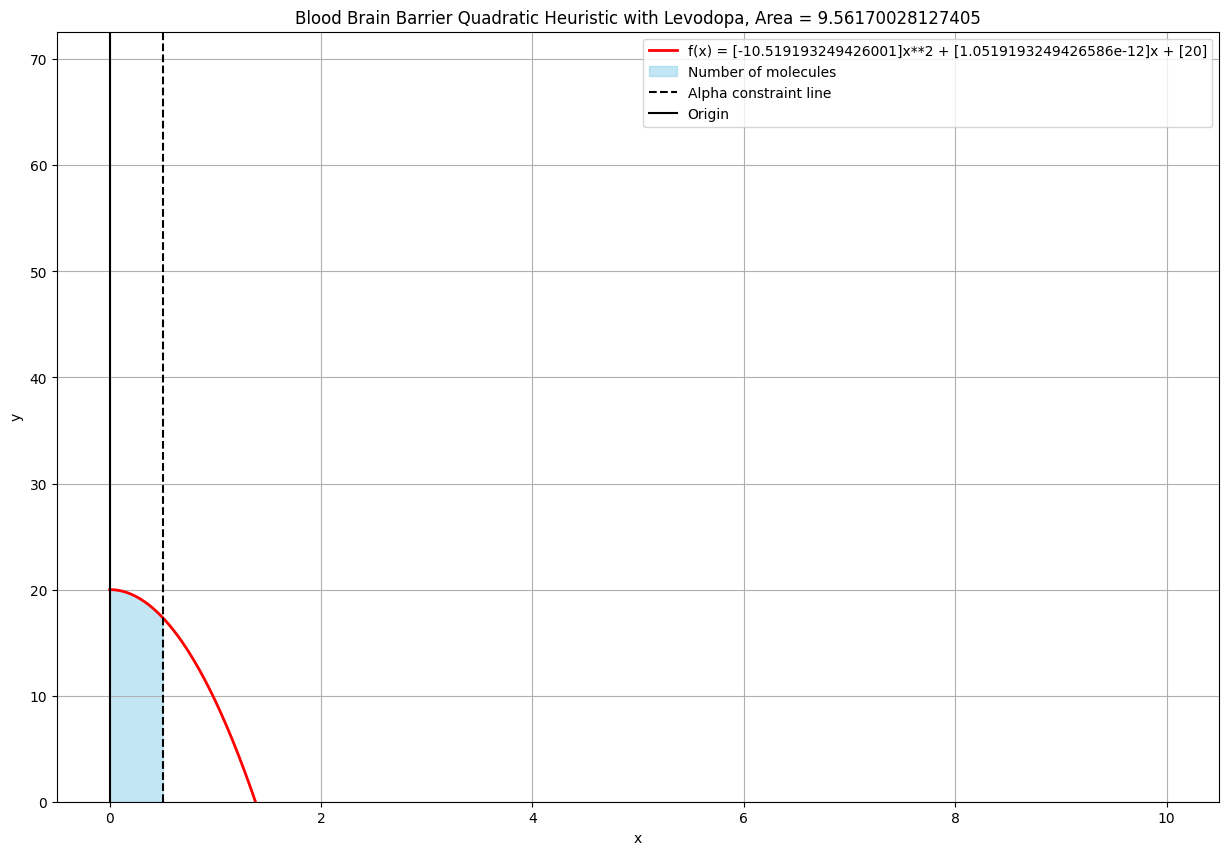

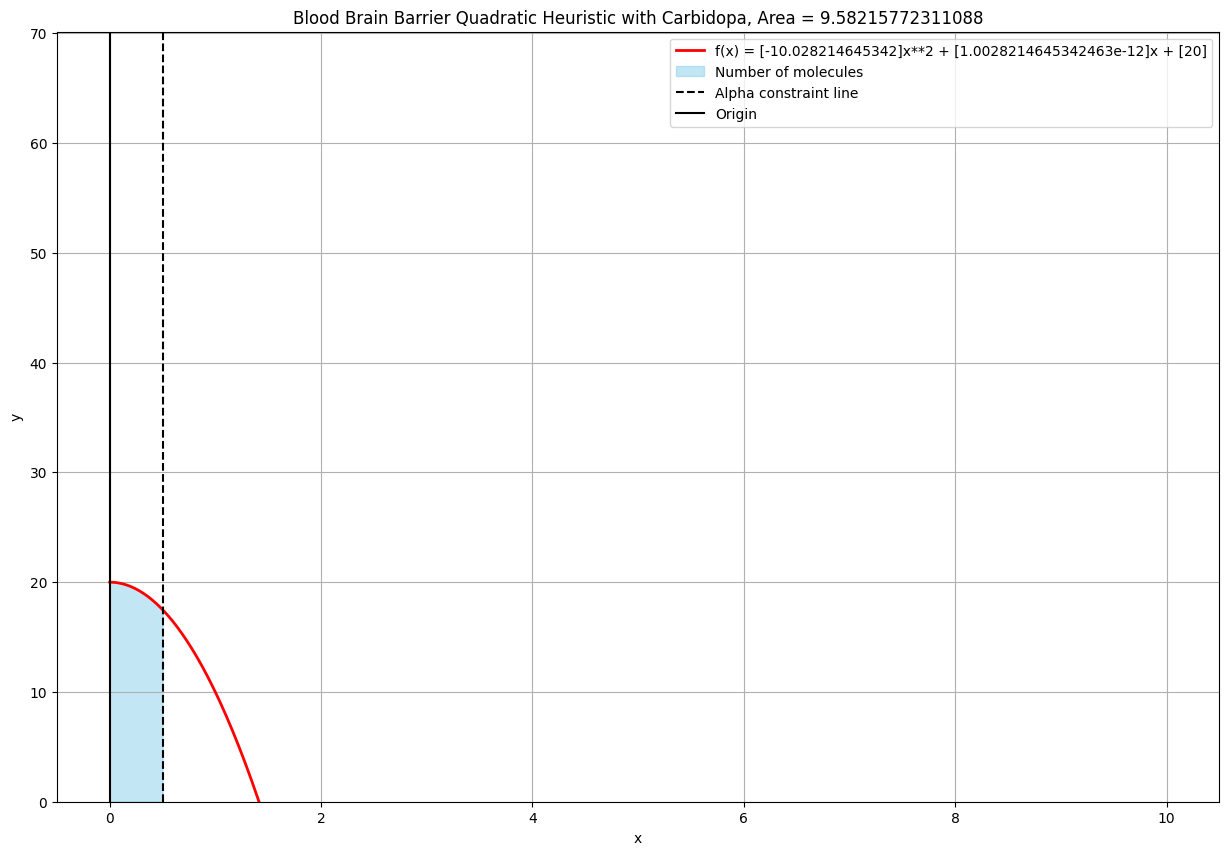

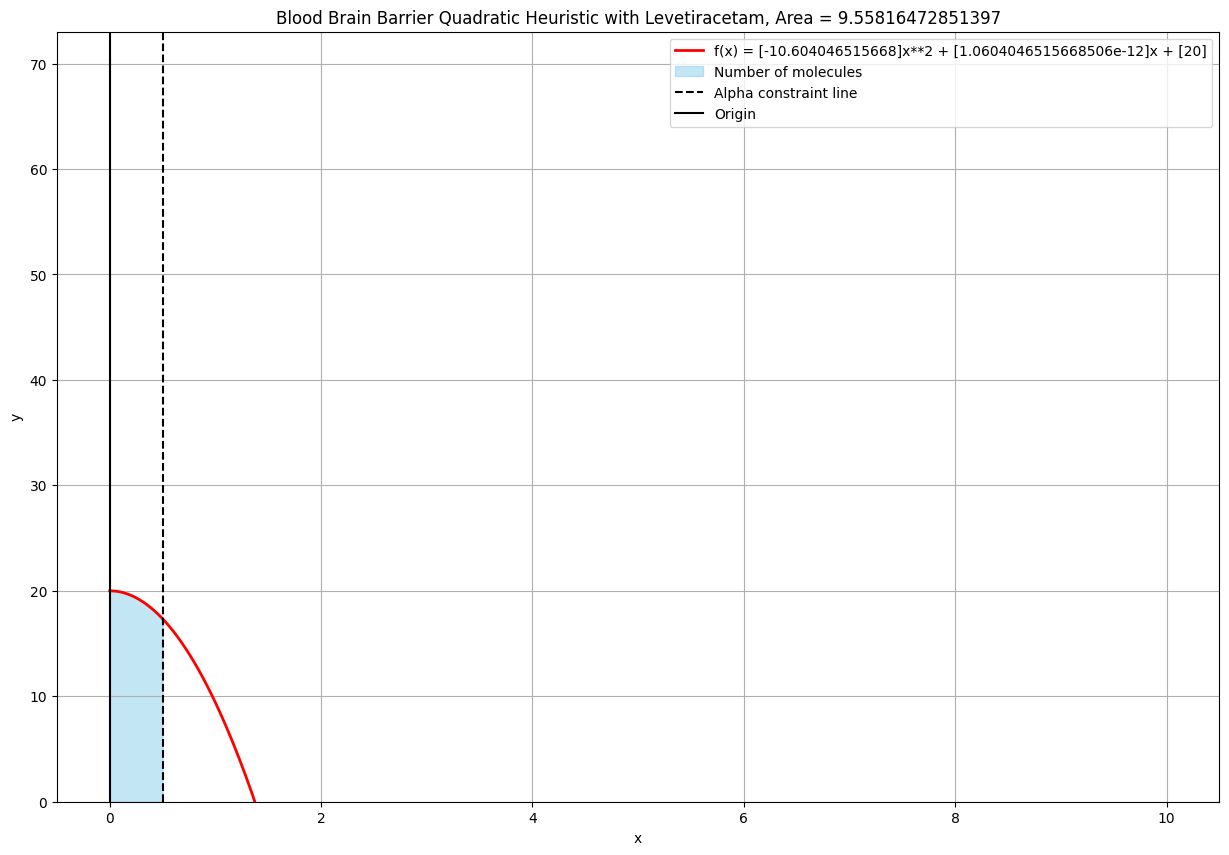

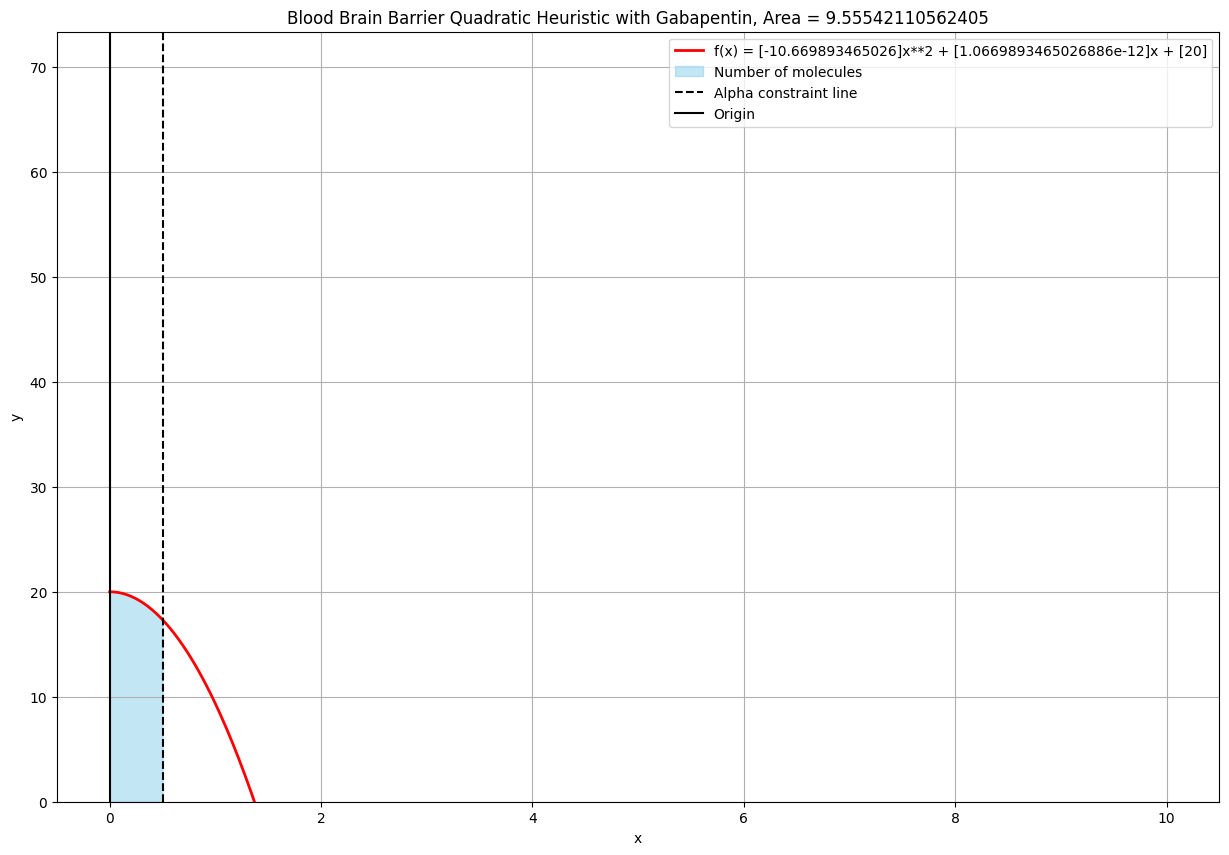

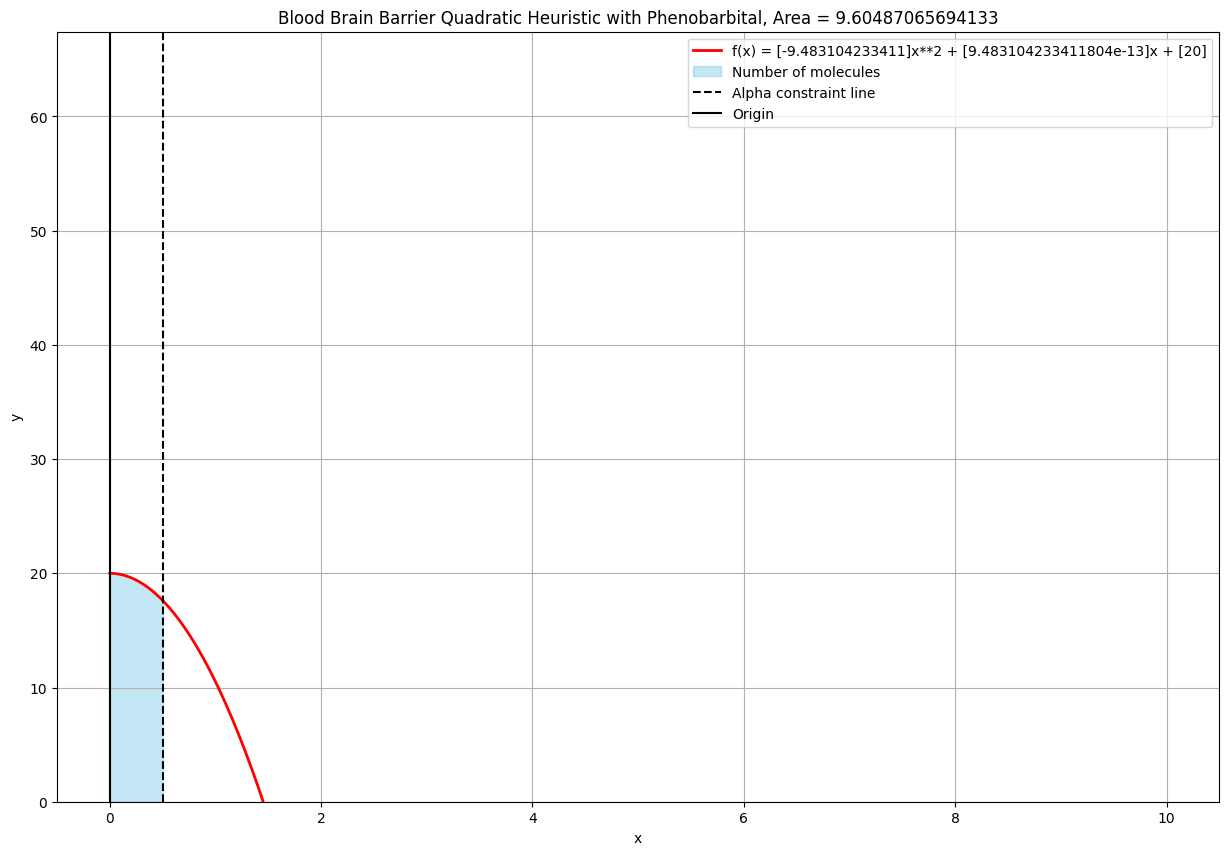

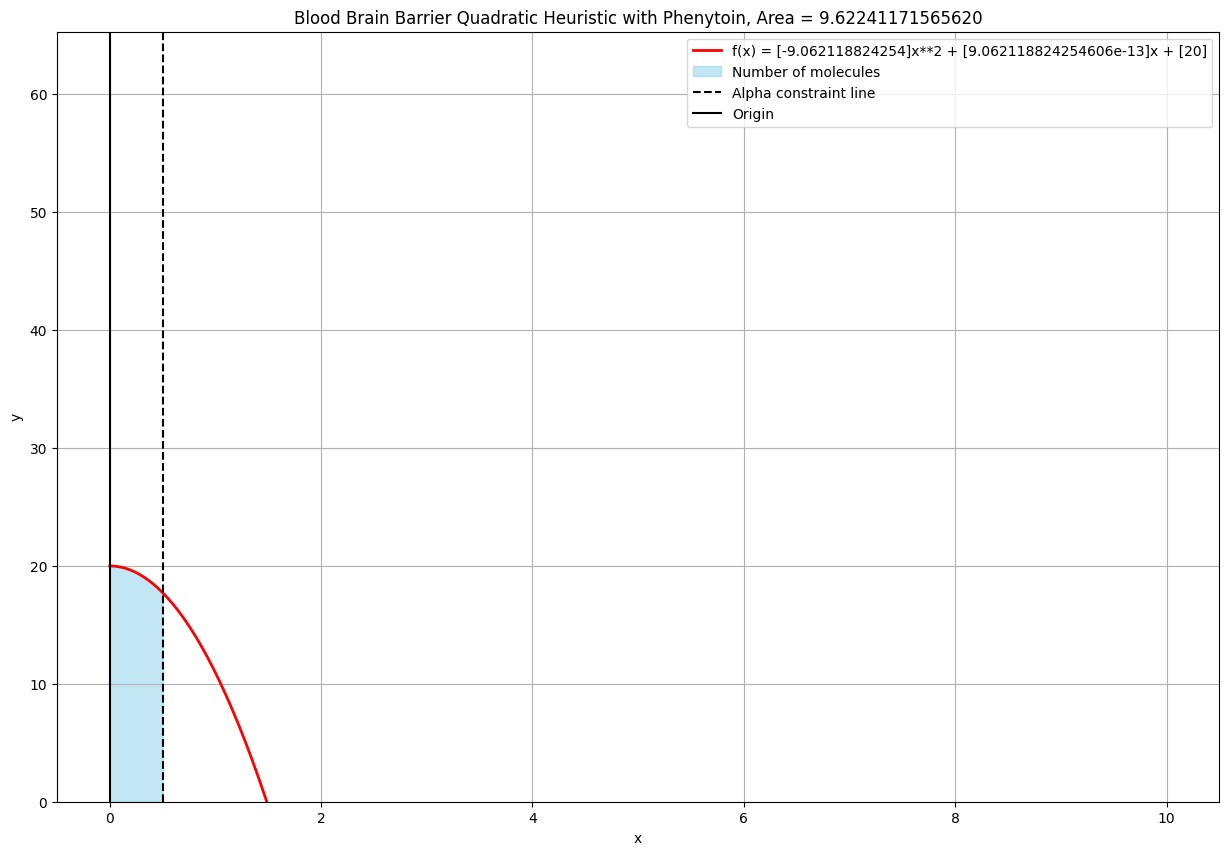

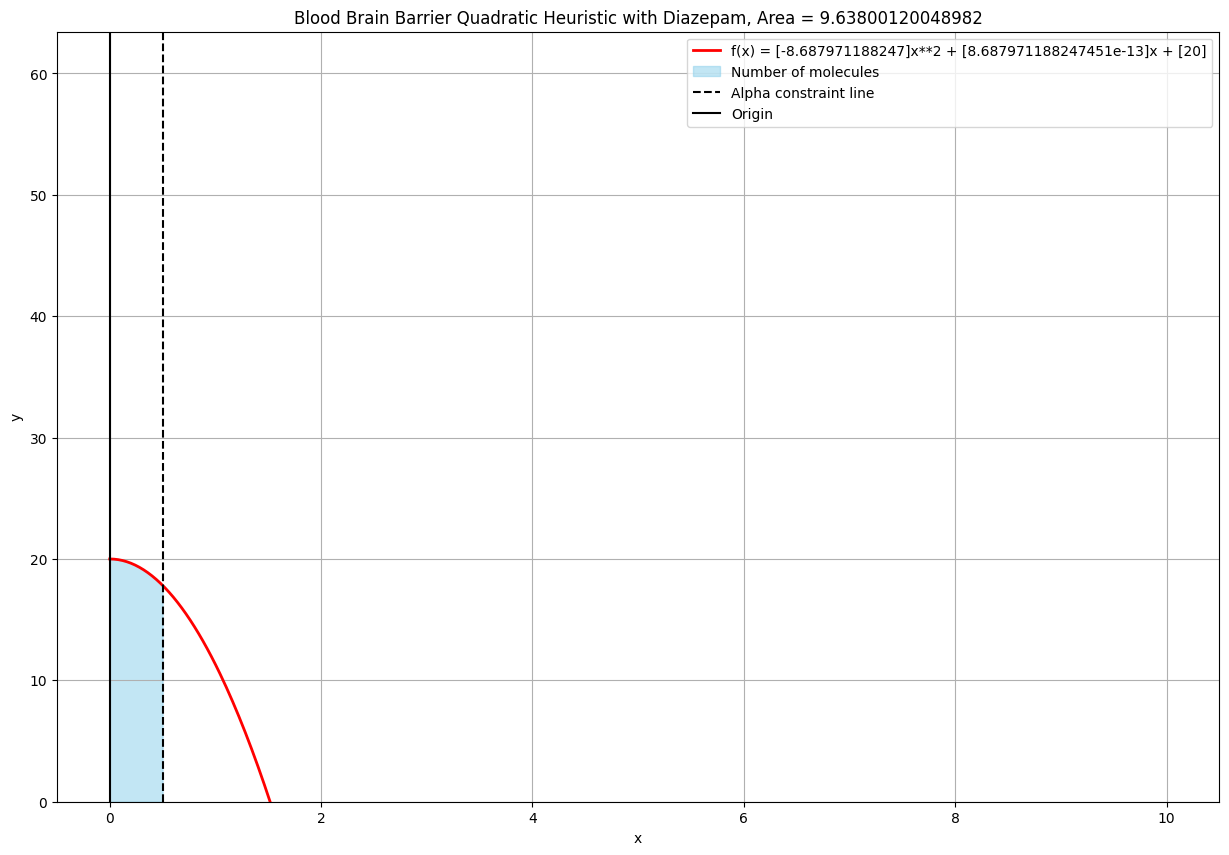

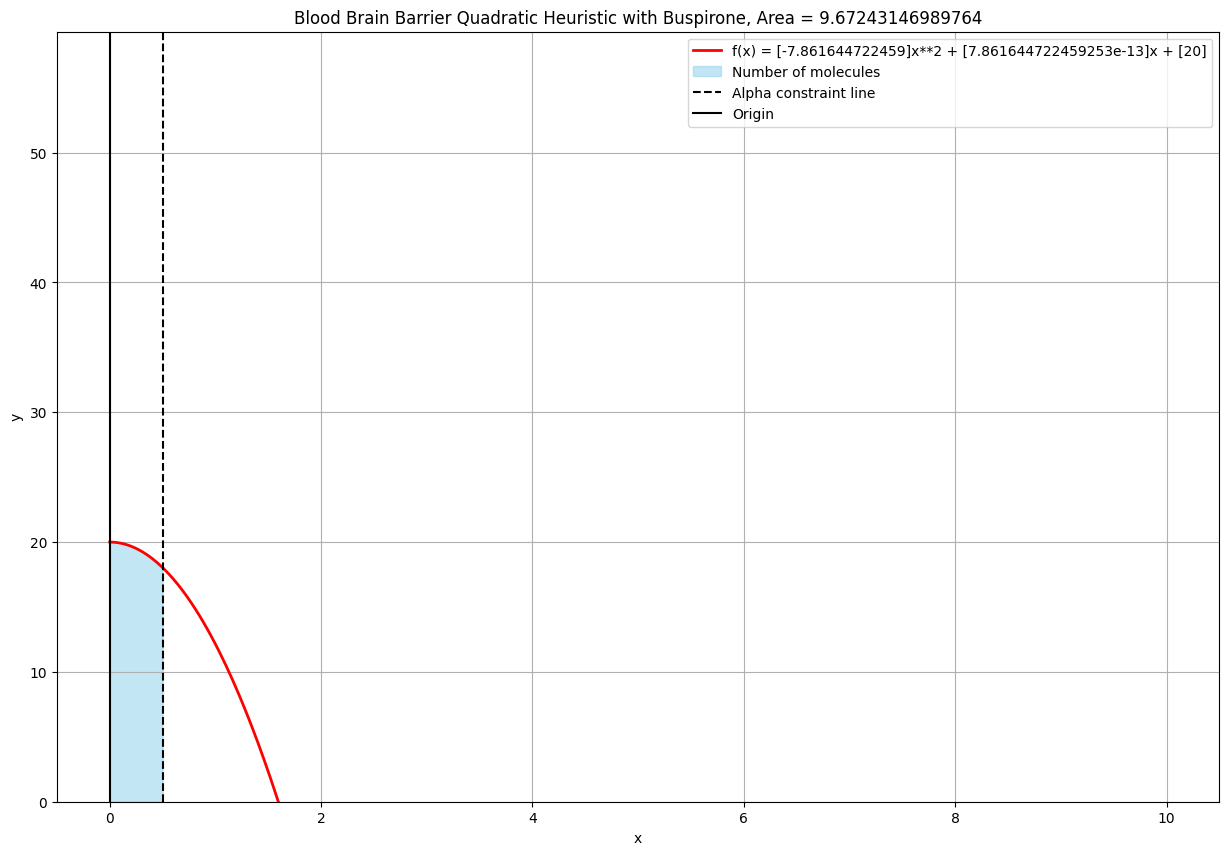

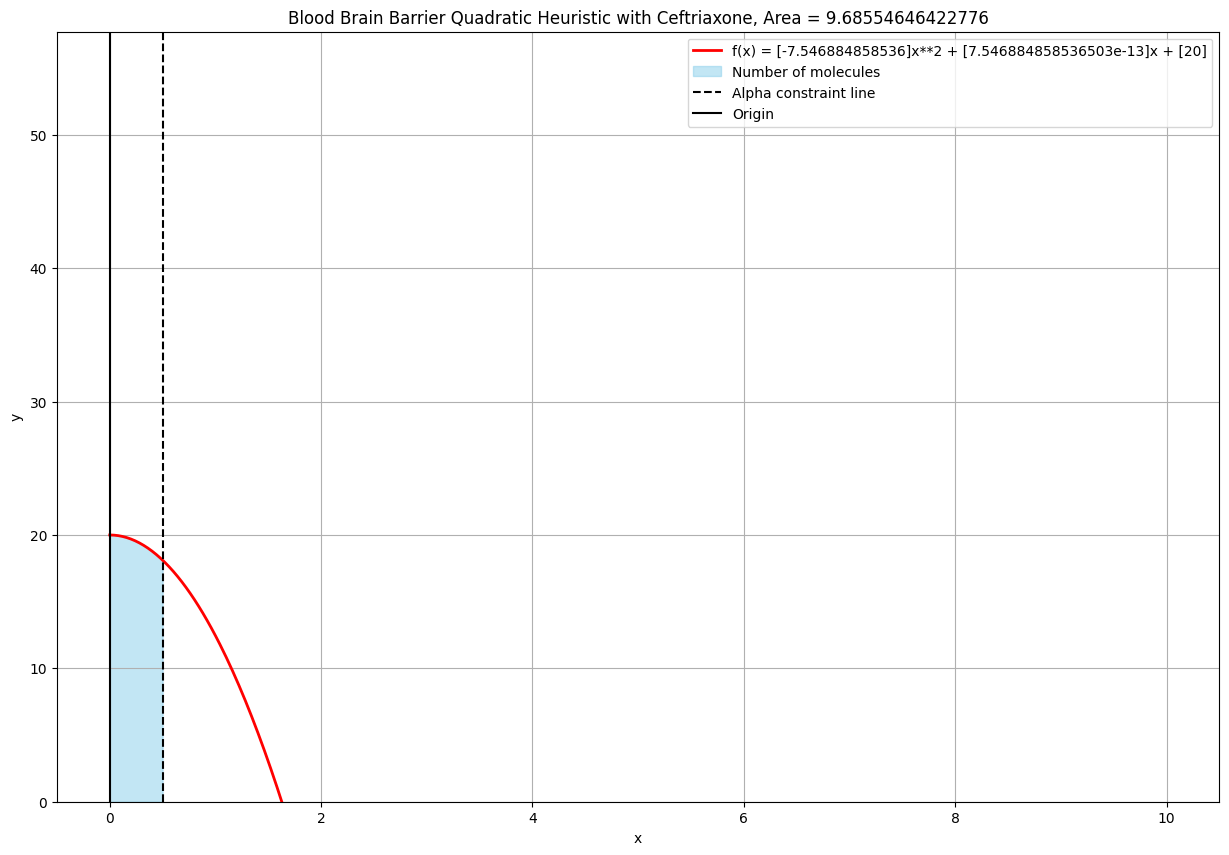

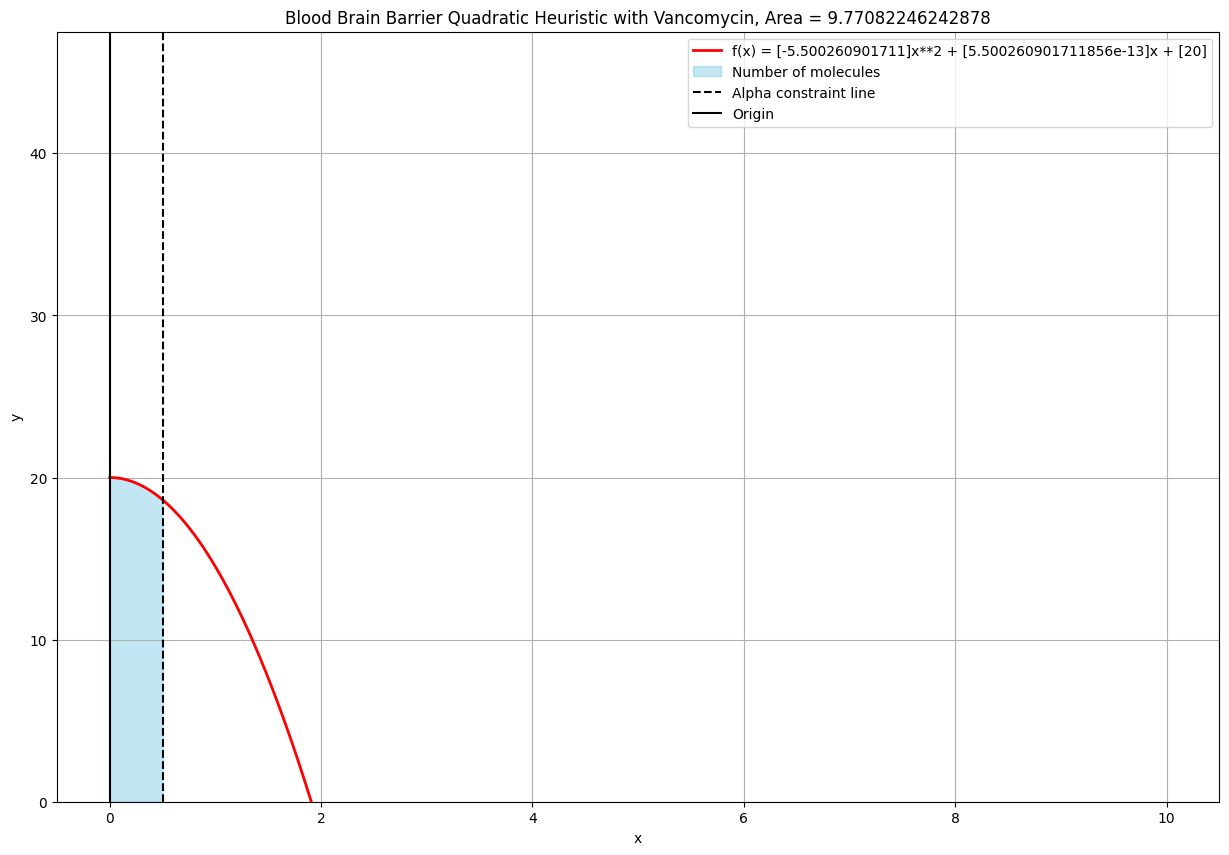

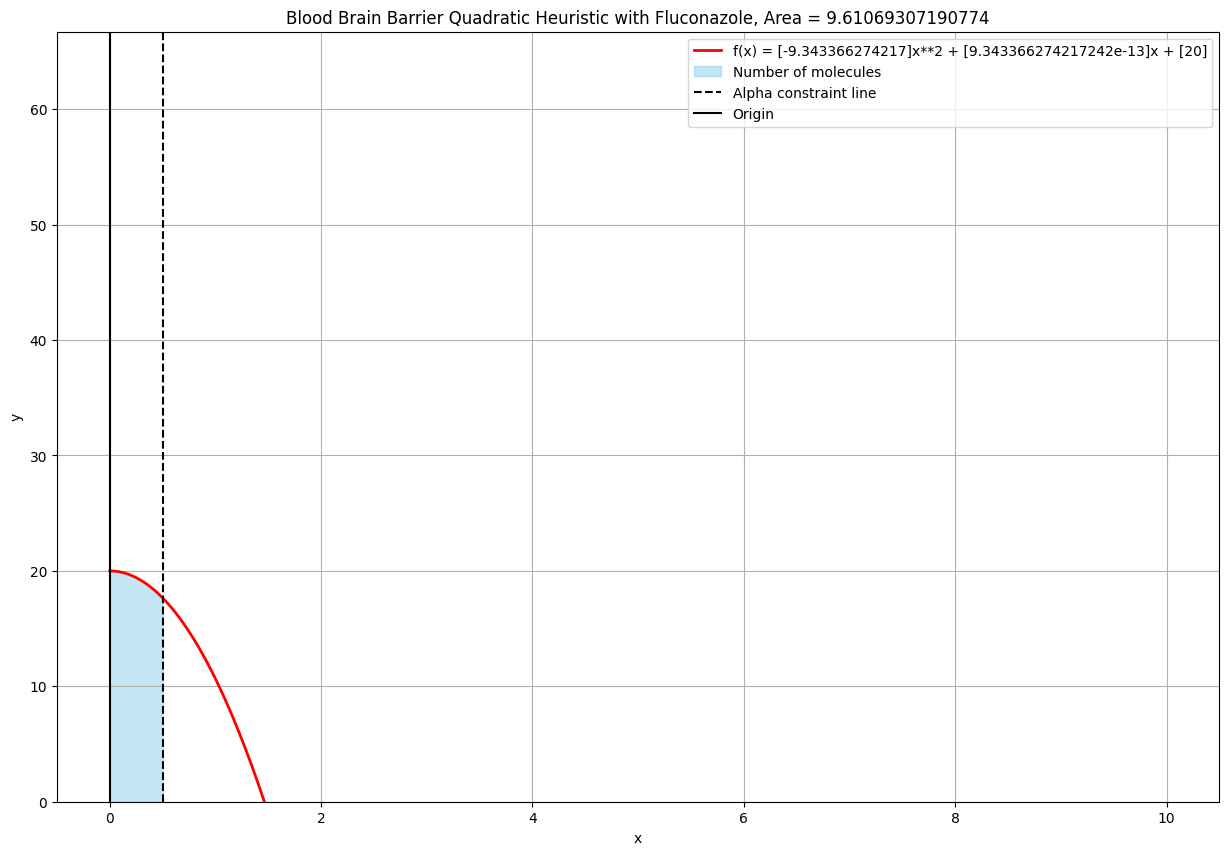

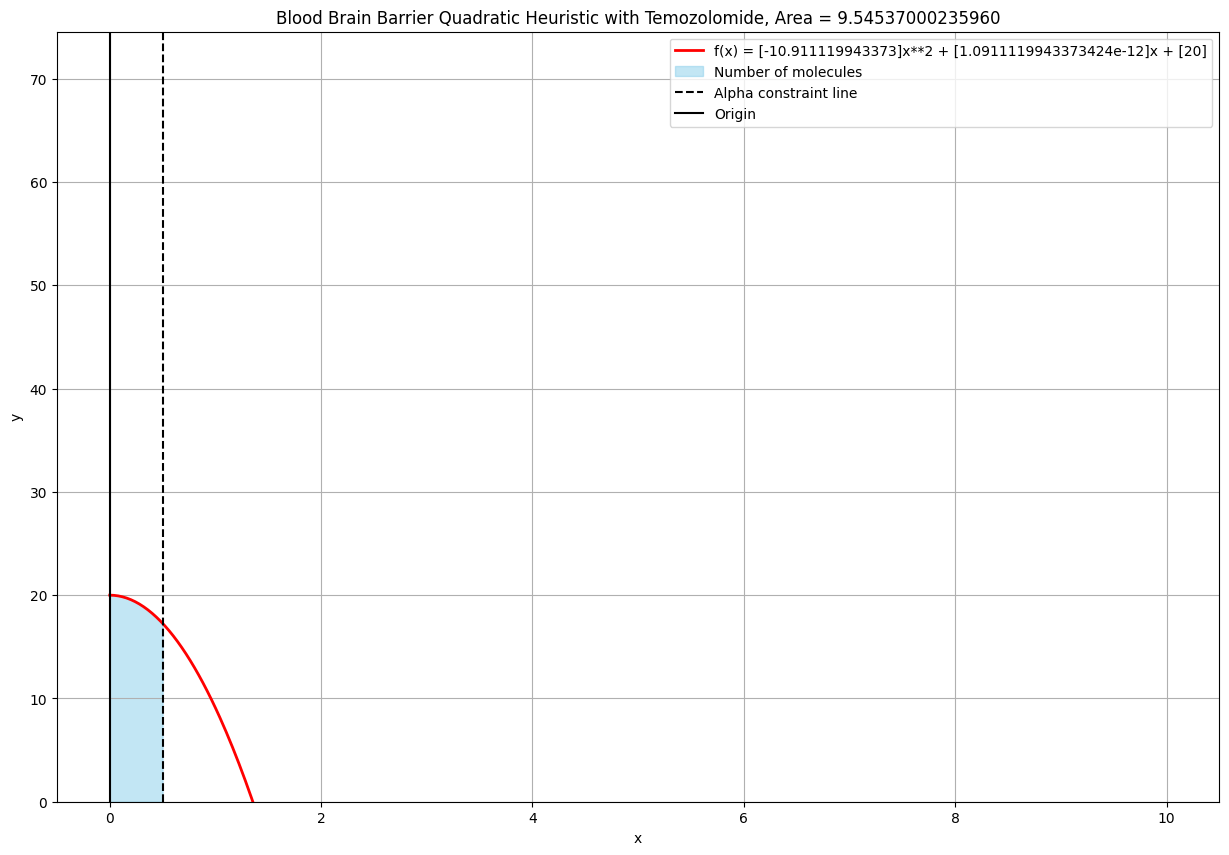

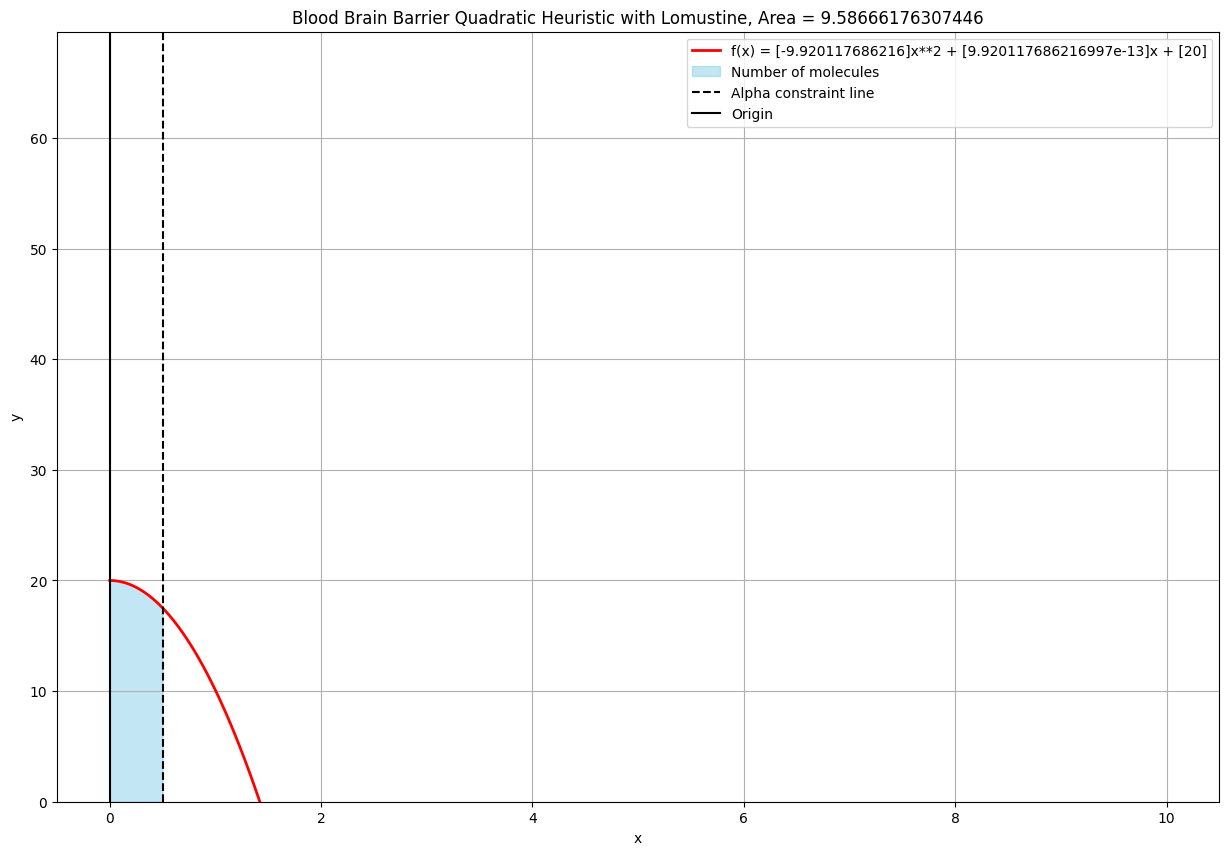

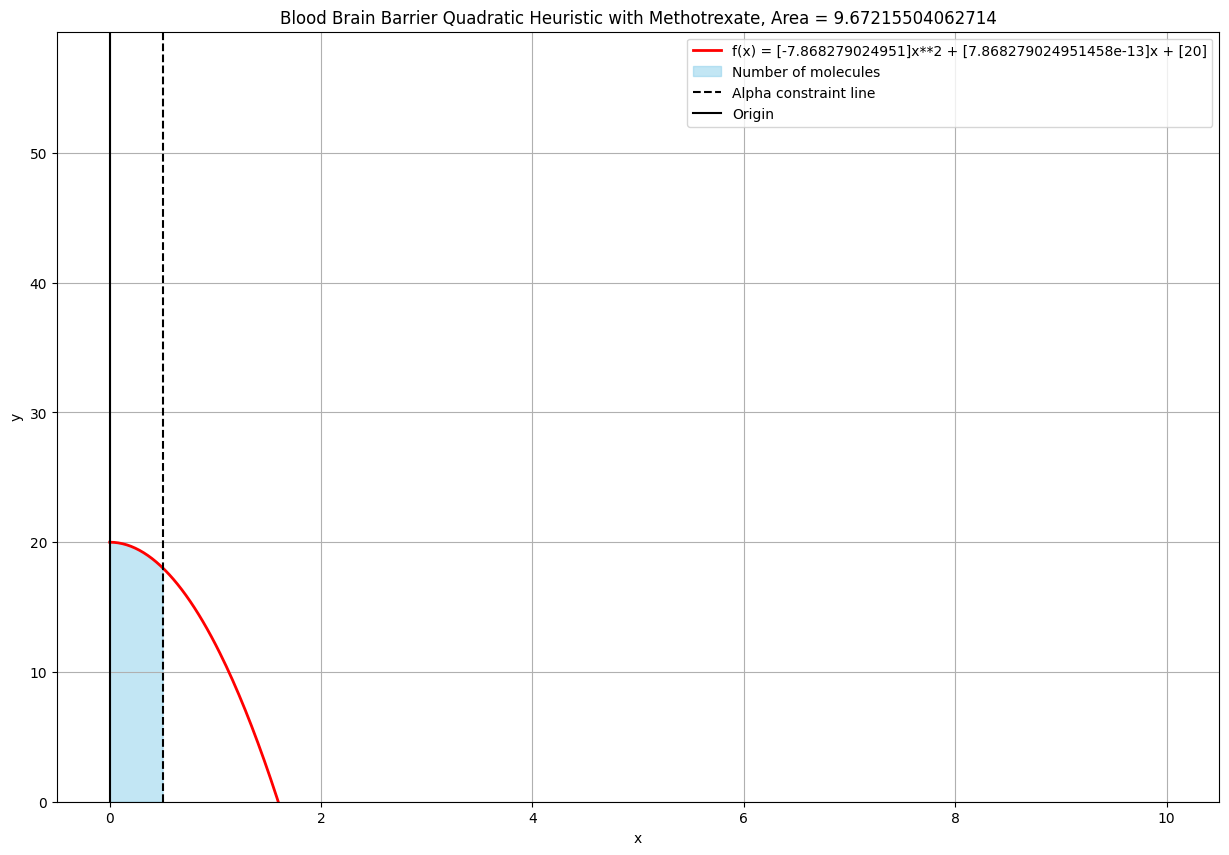

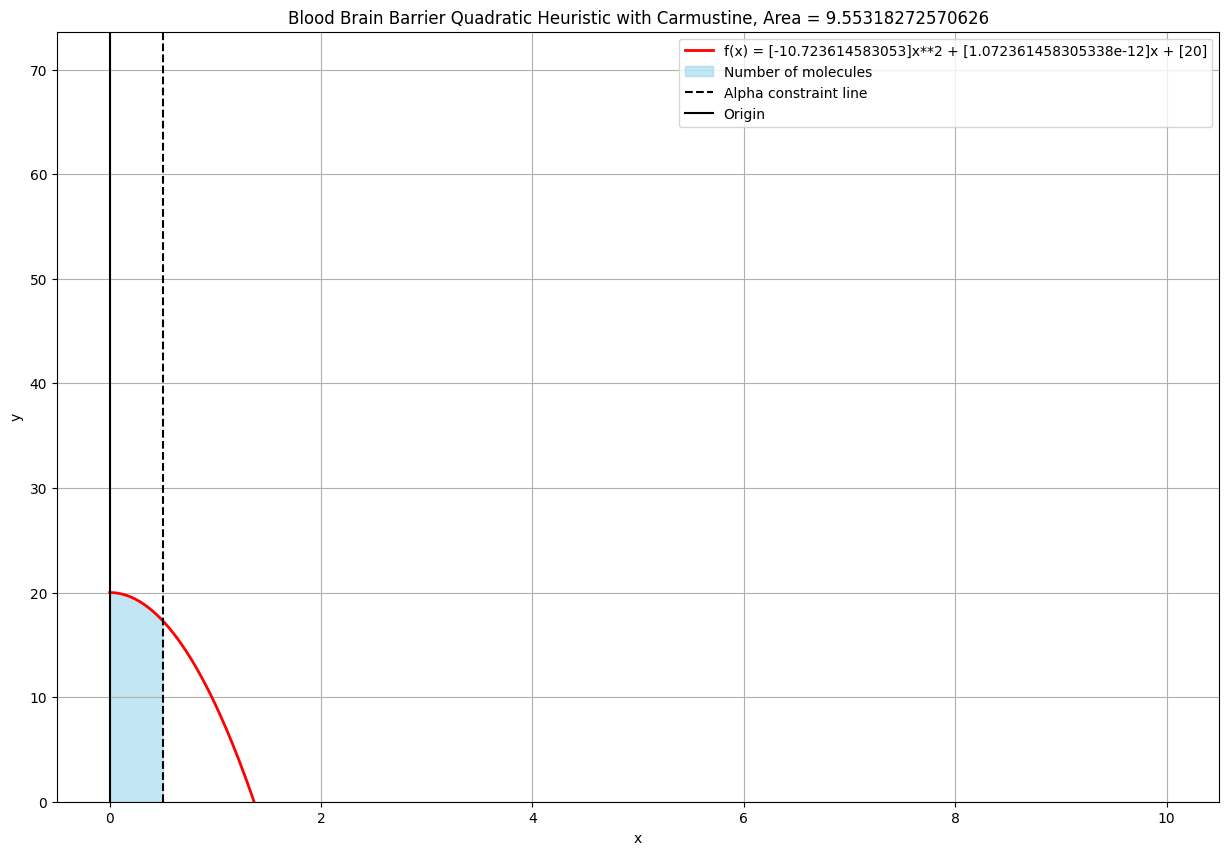

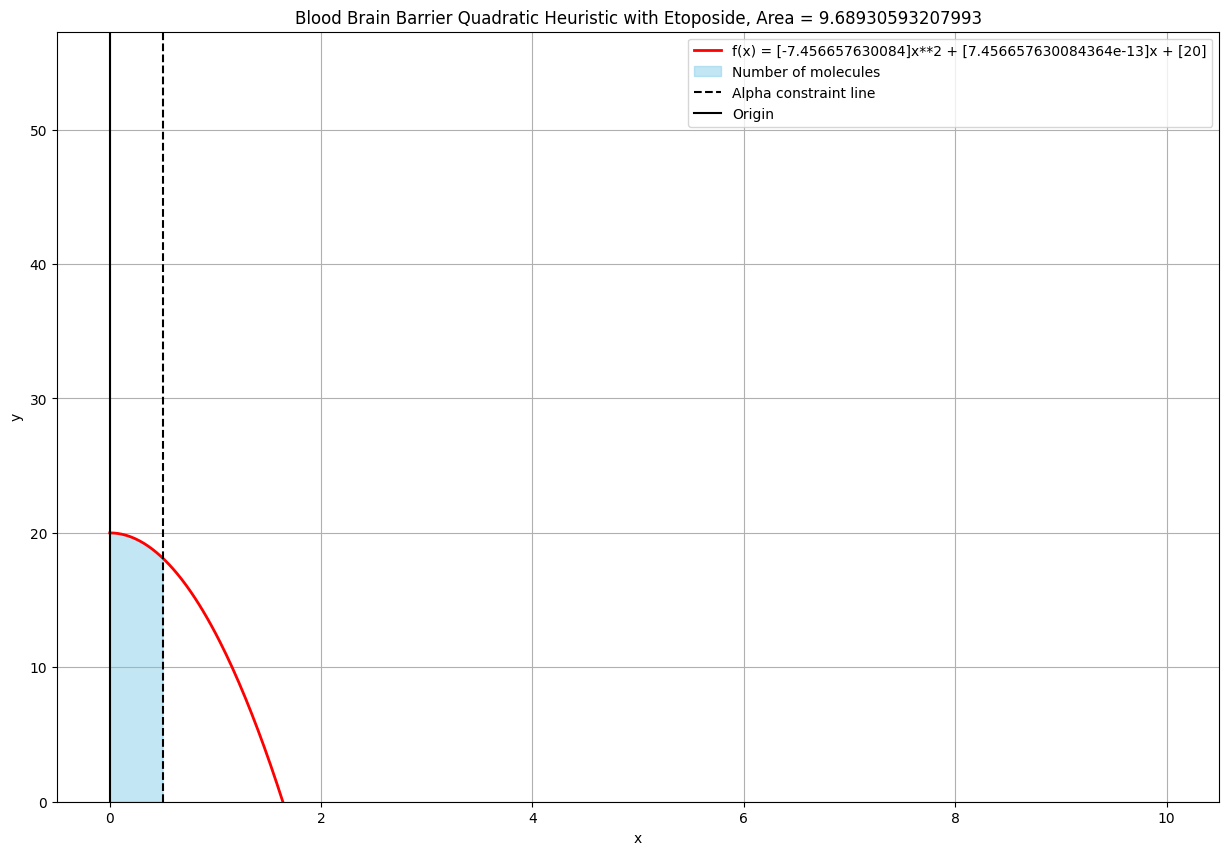

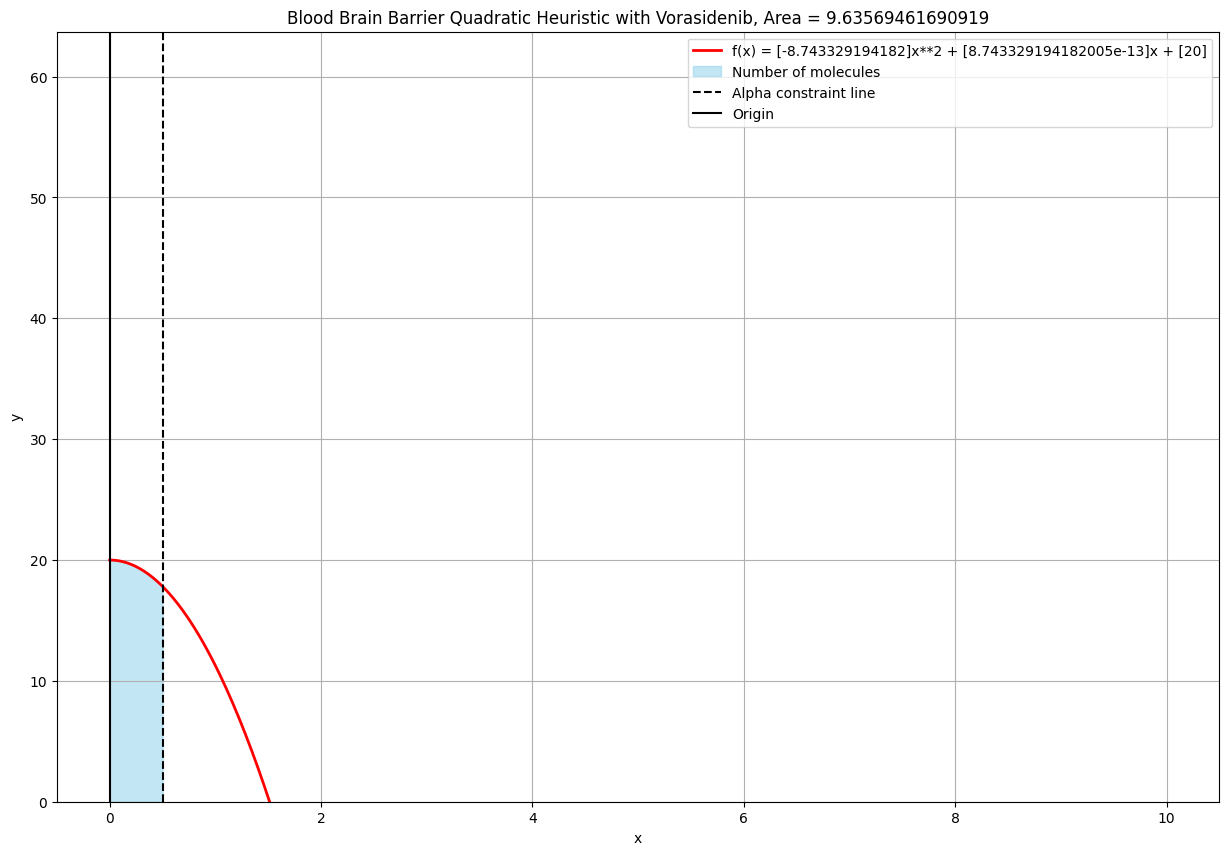

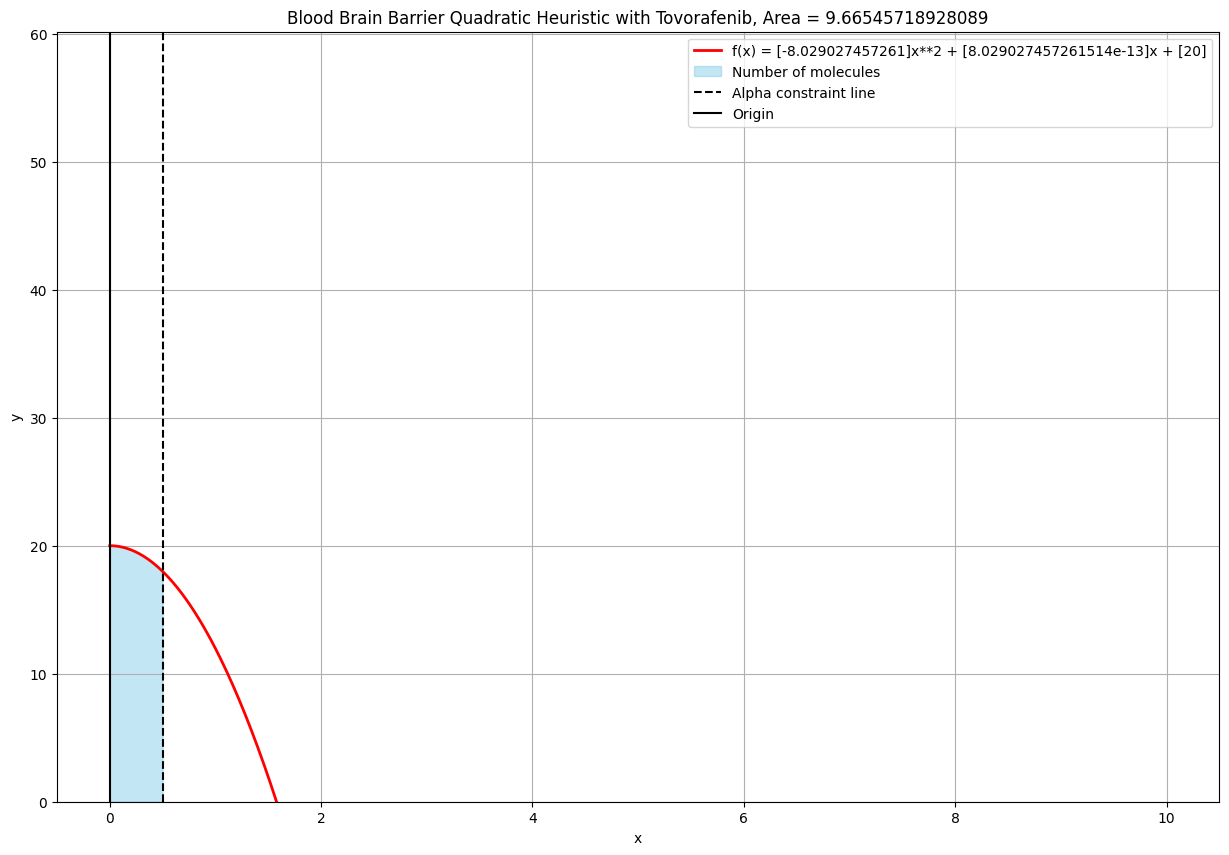

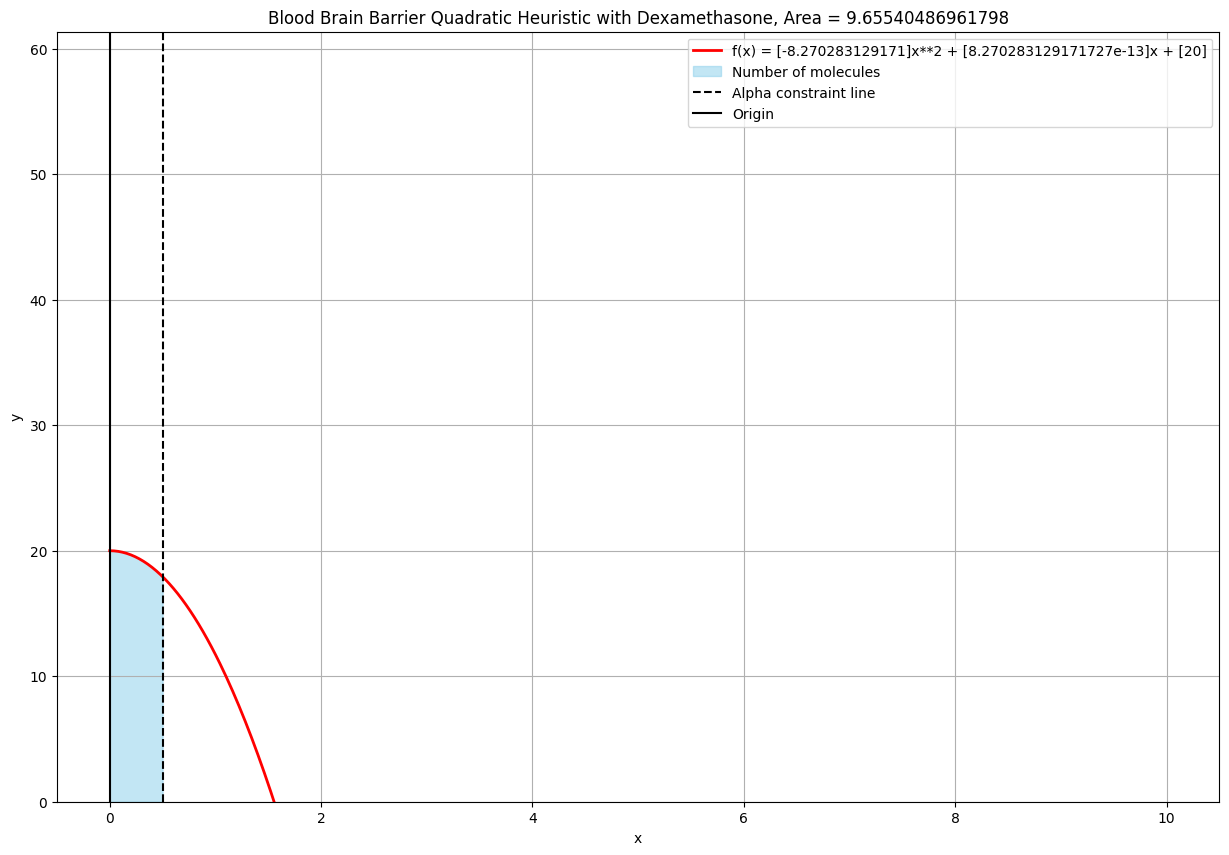

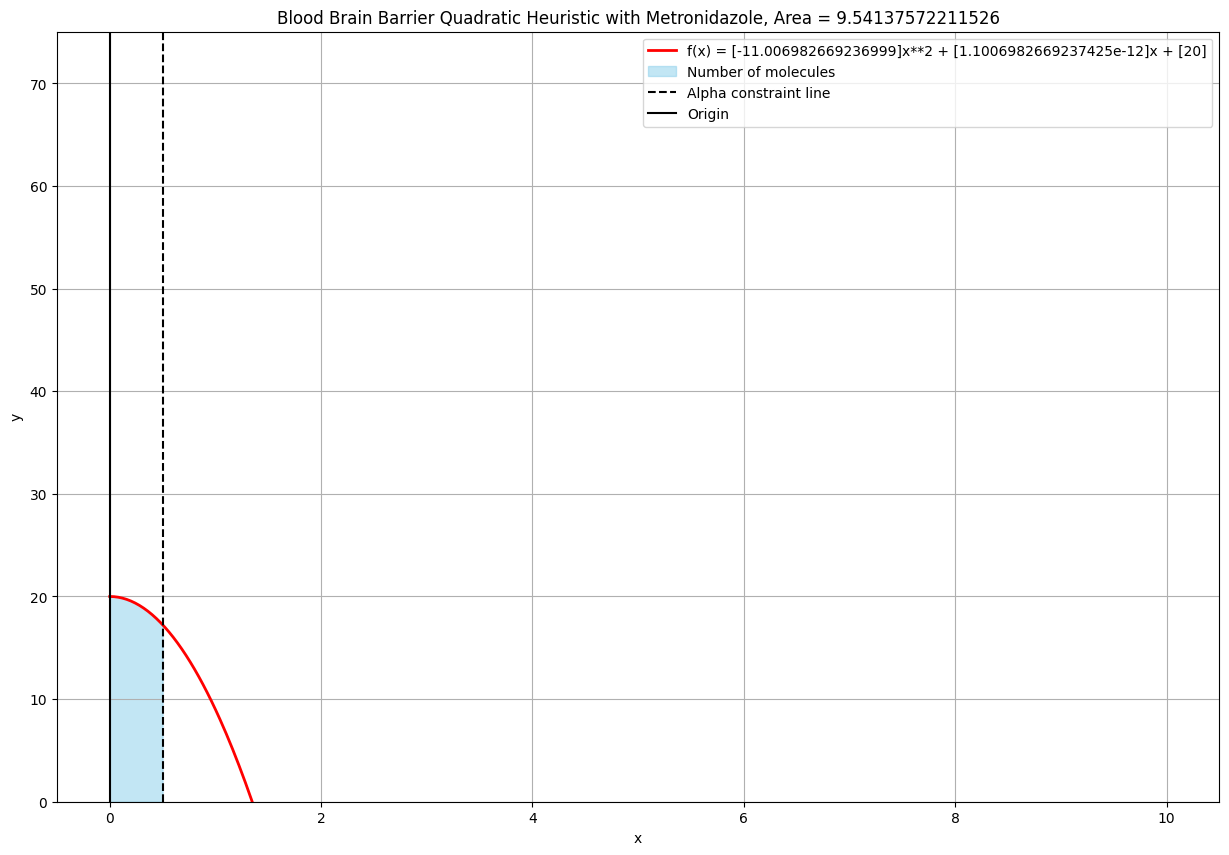

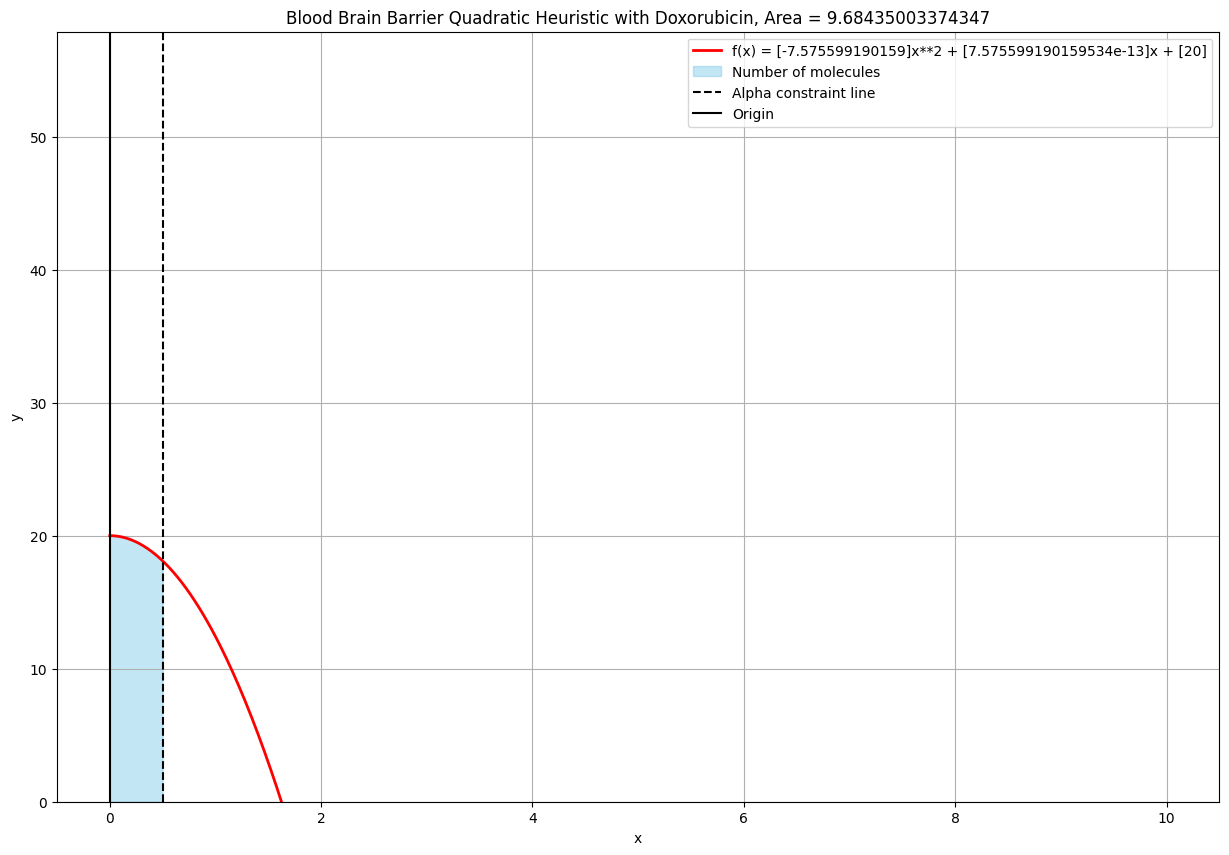

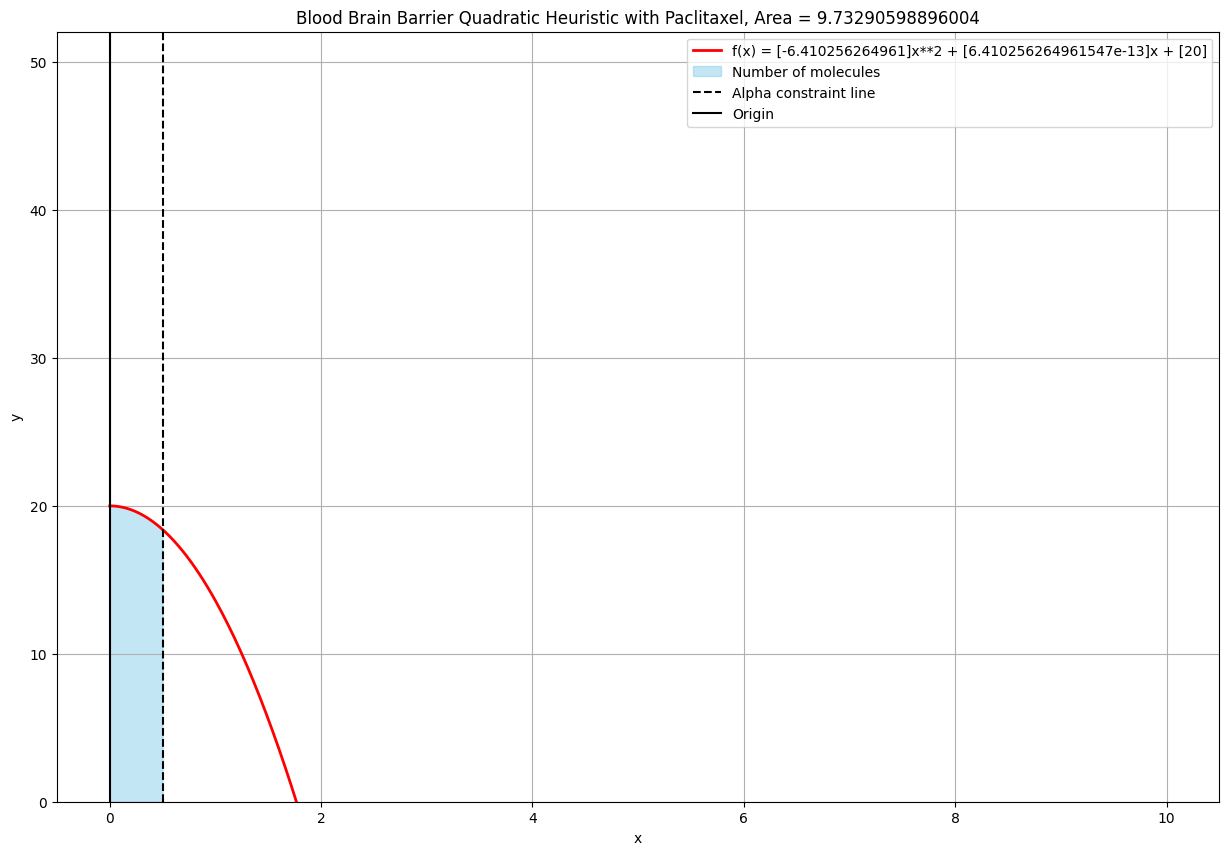

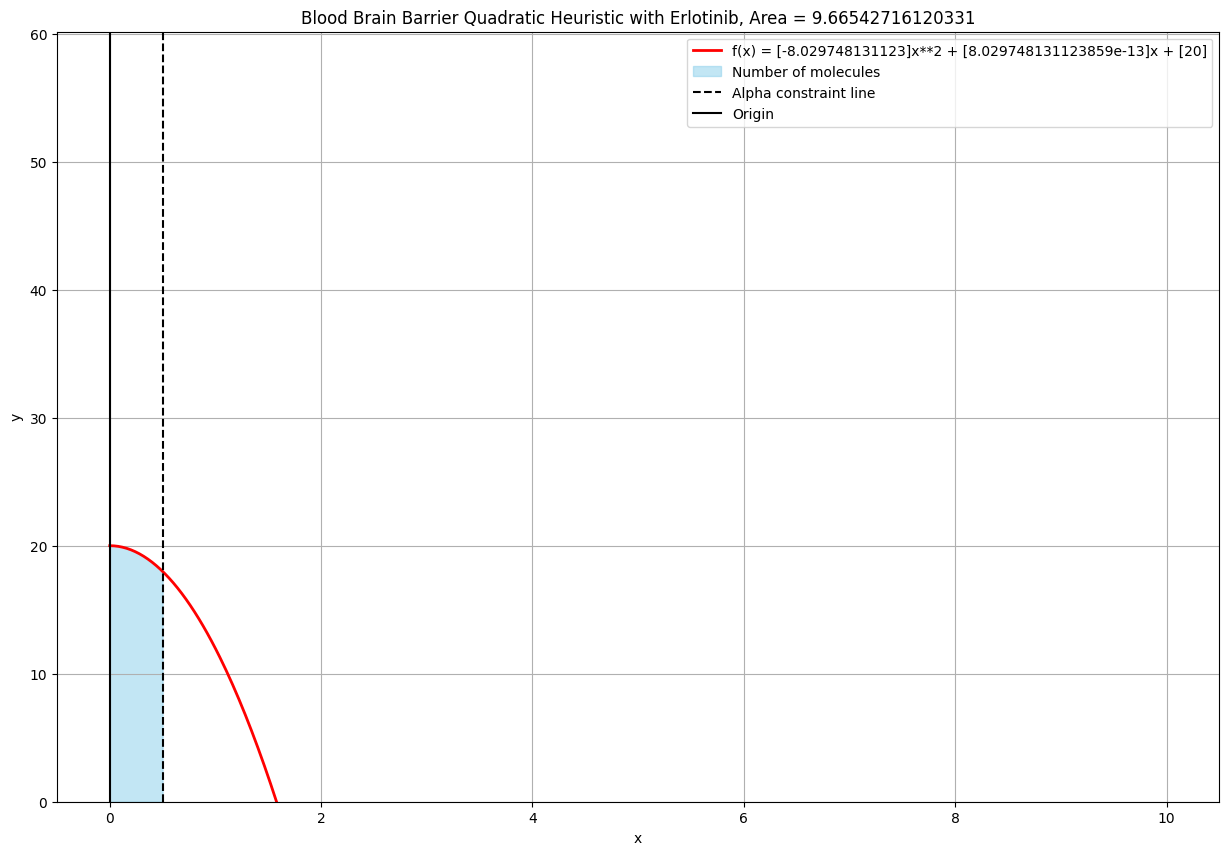

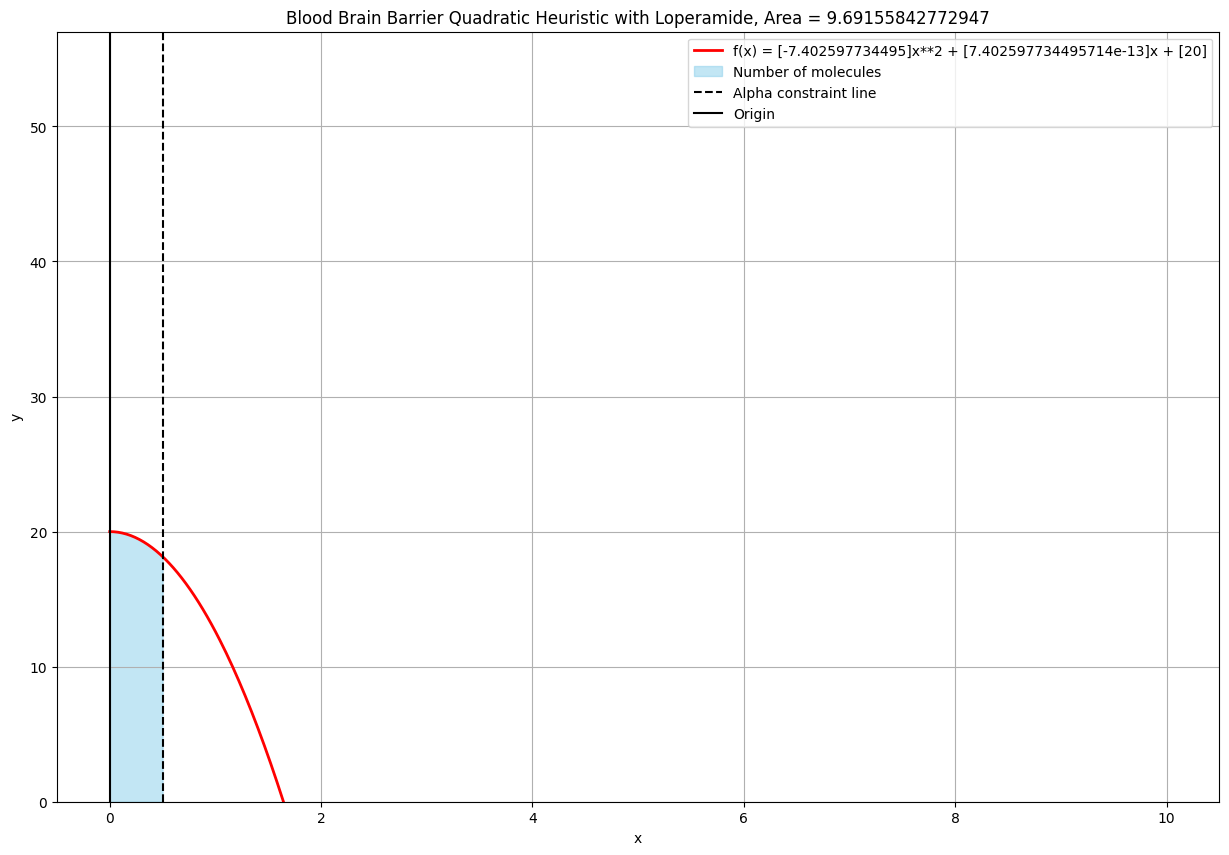

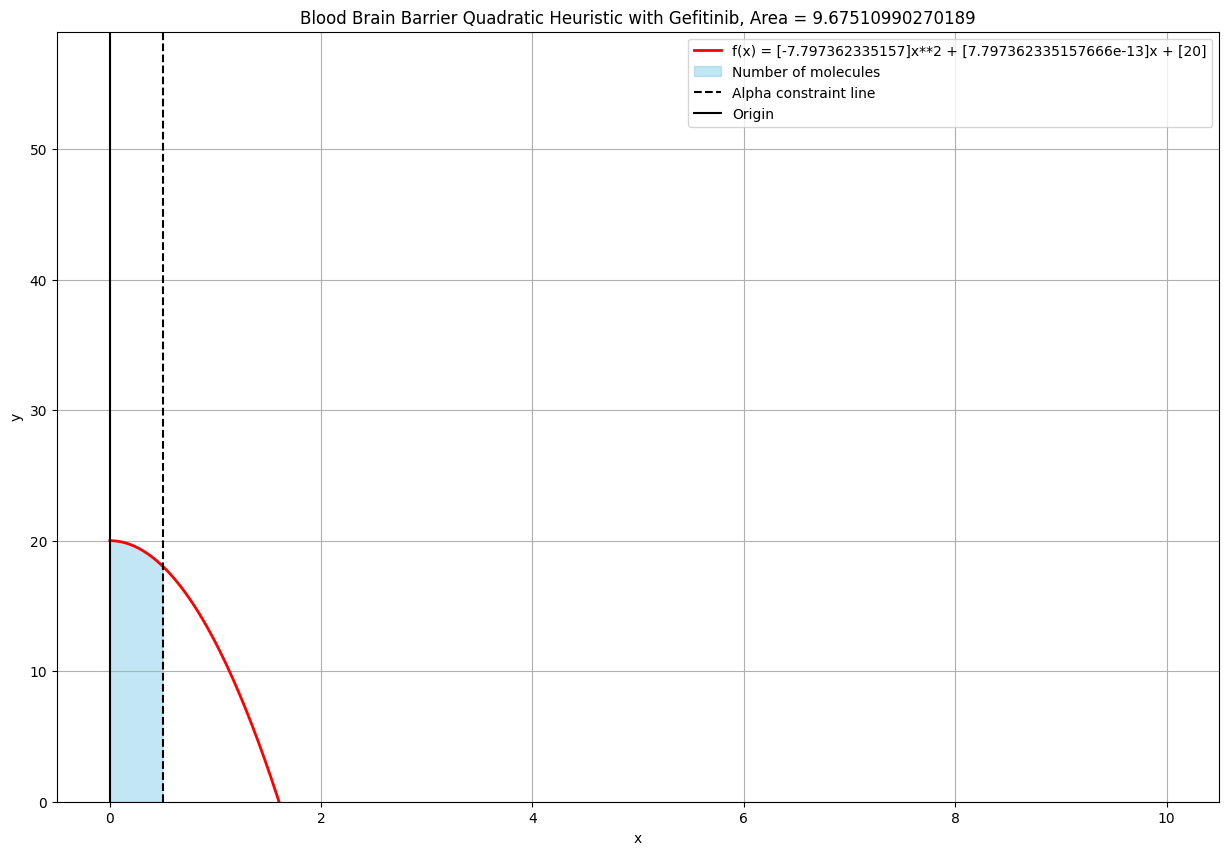

,Chemical Name,Area
0,Levodopa,9.56170028127405
1,Carbidopa,9.58215772311088
2,Levetiracetam,9.55816472851397
3,Gabapentin,9.55542110562405
4,Phenobarbital,9.60487065694133
5,Phenytoin,9.62241171565620
6,Diazepam,9.63800120048982
7,Buspirone,9.67243146989764
8,Ceftriaxone,9.68554646422776
9,Vancomycin,9.77082246242878


Calculated areas list saved to chemical_areas.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import re
import pandas as pd

areas_li = []

def plot_individual_heuristic(row):
    heuristic_str = row['Heuristic']
    chemical_name = row['Chemical Name']

    match = re.match(r"f\(x\) = \[(.*?)\]x\*\*2 \+ \[(.*?)\]x \+ \[(.*?)\]", heuristic_str)
    if match:
        alpha_val = float(match.group(1))
        beta_val = float(match.group(2))
        epsilon_val = float(match.group(3))
    else:
        print(f"Could not parse heuristic string: {heuristic_str}")
        return

    quadratic_func = lambda x: alpha_val * x**2 + beta_val * x + epsilon_val

    x_sym = sp.Symbol('x')
    f = quadratic_func(x_sym)
    a, b = 0, 0.5

    definite_integral = sp.integrate(f, (x_sym,a,b))

    areas_li.append({
      "Chemical Name": chemical_name,
      "Area": definite_integral
    })

    x = np.linspace(0, 10, 500)
    y = quadratic_func(x)

    a, b = 0, 0.5
    dx = np.linspace(a, b, 100)
    dy = quadratic_func(dx)

    fig, ax = plt.subplots(figsize=(15, 10))
    ax.plot(x, y, 'r', linewidth=2, label=f'{heuristic_str}')
    ax.set_ylim(bottom=0)

    ax.fill_between(dx, dy, color='skyblue', alpha=0.5, label=f'Number of molecules')
    plt.axvline(x=0.5, linestyle='--', color="black", label='Alpha constraint line')
    plt.axvline(x=0, color="black", label='Origin')

    ax.set_title(f'Blood Brain Barrier Quadratic Heuristic with {chemical_name}, Area = {definite_integral}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)

    plt.show()

for index, row in combined_new.iterrows():
  plot_individual_heuristic(row)

areas_df = pd.DataFrame(areas_li)

display(areas_df)

output_filename_areas = "chemical_areas.csv"
areas_df.to_csv(output_filename_areas, index=False)

output_filename_areas = "chemical_areas.csv"
areas_df.to_csv(output_filename_areas, index=False)
print(f"Calculated areas list saved to {output_filename_areas}")

colab.files.download(output_filename_areas)

**Heatmap creation for Heuristic Calculations using Min-Max Normalization**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pull_area = pd.read_csv('chemical_areas.csv')
pull_calculated = pd.read_csv('calculations.csv')
pull_chemical = pd.read_csv('chemical.csv')

pull_name = pull_chemical['Chemical Name:']
pull_mag =  pull_calculated['J-Magnitude']
pull_dif = pull_calculated['Diffusion Constant']
pull_Aprime = pull_area['Area']
pull_MW = pull_chemical['MW:']
pull_BTB = 0.004
pull_polarity = pull_chemical['WPC/OPC:']

collected_data = pd.DataFrame ({
    'Chemical Name': pull_name,
    'J-Magnitude': pull_mag,
    'Diffusion Constant': pull_dif,
    'Area': pull_Aprime,
    'Molecular Weight': pull_MW,
    'Viscosity': pull_BTB,
    'Proxy Polarity': abs(pull_polarity)
})

display(collected_data)

from IPython.display import Markdown, display
display(Markdown('---'))

def normalization_function(input):
  return (input - input.min()) / (input.max() - input.min())

rank_data = collected_data.copy()
categories = ['J-Magnitude', 'Diffusion Constant', 'Area', 'Molecular Weight', 'Proxy Polarity']

for col in categories:
  rank_data[col] = normalization_function(collected_data[col])

display(rank_data)
output_filename_rank = 'rank.csv'
rank_data.to_csv(output_filename_rank, index=False)
print(f"Data saved to {output_filename_rank}")

output_filename_collected = 'collected_metrics.csv'
collected_data.to_csv(output_filename_collected, index=False)
print(f"Raw metrics saved to {output_filename_collected}")
colab.files.download(output_filename_collected)

output_filename_rank = 'rank.csv'
rank_data.to_csv(output_filename_rank, index=False)
print(f"Normalized scaling data saved to {output_filename_rank}")
colab.files.download(output_filename_rank)

,Chemical Name,J-Magnitude,Diffusion Constant,Area,Molecular Weight,Viscosity,Proxy Polarity
0,Levodopa,0.001052,2.103839e-10,9.561700,197.19,0.004,2.7
1,Carbidopa,0.001003,2.005643e-10,9.582158,226.23,0.004,2.2
2,Levetiracetam,0.001060,2.120809e-10,9.558165,170.21,0.004,0.3
3,Gabapentin,0.001067,2.133979e-10,9.555421,171.24,0.004,1.1
4,Phenobarbital,0.000948,1.896621e-10,9.604871,232.23,0.004,1.5
5,Phenytoin,0.000906,1.812424e-10,9.622412,252.27,0.004,2.5
6,Diazepam,0.000869,1.737594e-10,9.638001,284.74,0.004,3.0
7,Buspirone,0.000786,1.572329e-10,9.672431,385.50,0.004,2.6
8,Ceftriaxone,0.000755,1.509377e-10,9.685546,554.60,0.004,1.3
9,Vancomycin,0.000550,1.100052e-10,9.770822,1449.20,0.004,2.6


---

,Chemical Name,J-Magnitude,Diffusion Constant,Area,Molecular Weight,Viscosity,Proxy Polarity
0,Levodopa,0.911419,0.911419,0.088581,0.021095,0.004,0.509434
1,Carbidopa,0.822259,0.822259,0.177741,0.043800,0.004,0.415094
2,Levetiracetam,0.926828,0.926828,0.073172,0.000000,0.004,0.056604
3,Gabapentin,0.938786,0.938786,0.061214,0.000805,0.004,0.207547
4,Phenobarbital,0.723269,0.723269,0.276731,0.048491,0.004,0.283019
5,Phenytoin,0.646820,0.646820,0.353180,0.064160,0.004,0.471698
6,Diazepam,0.578876,0.578876,0.421124,0.089547,0.004,0.566038
7,Buspirone,0.428818,0.428818,0.571182,0.168328,0.004,0.490566
8,Ceftriaxone,0.371659,0.371659,0.628341,0.300542,0.004,0.245283
9,Vancomycin,0.000000,0.000000,1.000000,1.000000,0.004,0.490566


Data saved to rank.csv
Raw metrics saved to collected_metrics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Normalized scaling data saved to rank.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

pull_rank = pd.read_csv('rank.csv')

def transform_equation(j_mag, diff_const, proxy_polarity, area, mw, viscosity_const):
  return j_mag + diff_const + proxy_polarity + (3 - area - mw - viscosity_const)

calculated_results = []
viscosity = 0.004

for index, row in pull_rank.iterrows():
  j_mag = row['J-Magnitude']
  diff_const = row['Diffusion Constant']
  proxy_polarity = row['Proxy Polarity']
  area = row['Area']
  mw = row['Molecular Weight']

  heat_map_number = transform_equation(j_mag, diff_const, proxy_polarity, area, mw, viscosity)

  calculated_results.append({
      'Chemical Name': row['Chemical Name'],
      'Heat Map Number': heat_map_number
  })

final_df = pd.DataFrame(calculated_results)

display(final_df)
output_filename_final = 'heatmap.csv'
final_df.to_csv(output_filename_final, index=False)
print(f"Data saved to {output_filename_final}")

output_filename_final = 'heatmap.csv'
final_df.to_csv(output_filename_final, index=False)
print(f"Data saved to {output_filename_final}")

colab.files.download(output_filename_final)

,Chemical Name,Heat Map Number
0,Levodopa,5.218597
1,Carbidopa,4.834072
2,Levetiracetam,4.833089
3,Gabapentin,5.019099
4,Phenobarbital,4.400336
5,Phenytoin,4.343998
6,Diazepam,4.209119
7,Buspirone,3.604693
8,Ceftriaxone,3.055719
9,Vancomycin,1.486566


Data saved to heatmap.csv
Data saved to heatmap.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Generate the Heatmap for visualization of results**

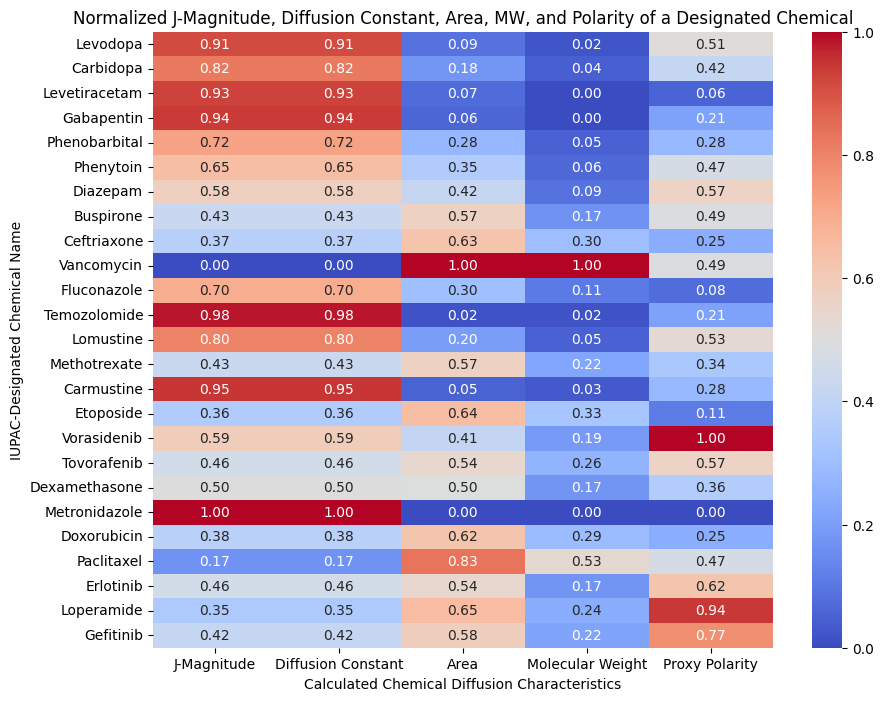

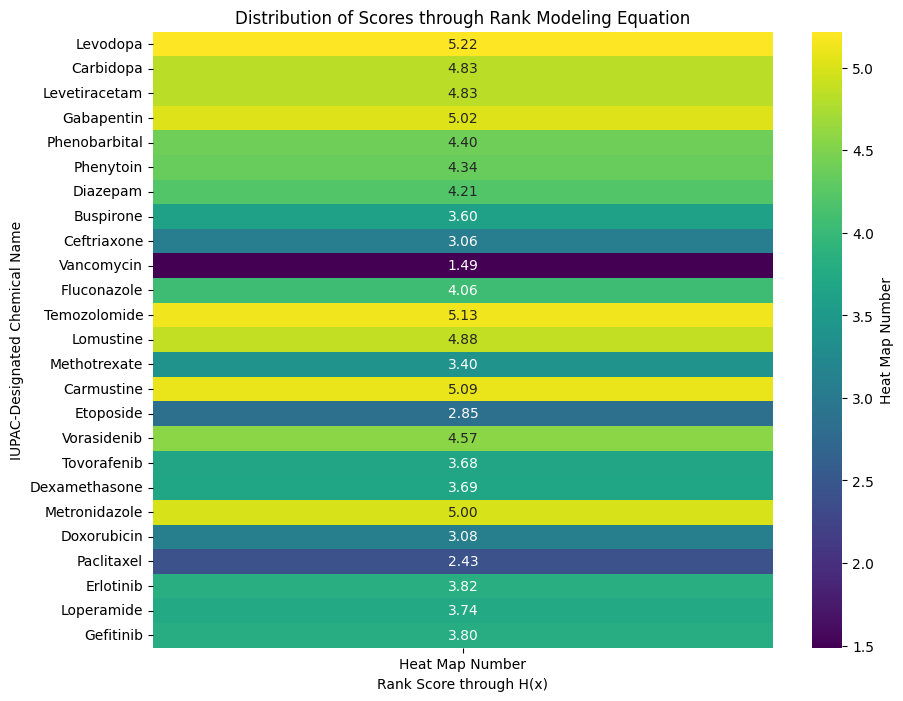

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

hm = pd.read_csv('final.csv')
nv = pd.read_csv('rank.csv')

score_map = hm.set_index('Chemical Name')[['Heat Map Number']]
map_data_full = nv.set_index('Chemical Name')[['J-Magnitude', 'Diffusion Constant', 'Area', 'Molecular Weight', 'Proxy Polarity']]

plt.figure(figsize=(10, 8))
sns.heatmap(map_data_full, annot=True, cmap = 'coolwarm', fmt=".2f")
plt.title('Normalized J-Magnitude, Diffusion Constant, Area, MW, and Polarity of a Designated Chemical')
plt.xlabel('Calculated Chemical Diffusion Characteristics')
plt.ylabel('IUPAC-Designated Chemical Name')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(score_map, annot=True, cmap='viridis', fmt=".2f", cbar_kws={'label': 'Heat Map Number'})
plt.title('Distribution of Scores through Rank Modeling Equation')
plt.xlabel('Rank Score through H(x)')
plt.ylabel('IUPAC-Designated Chemical Name')
plt.show()